# *🧠 Exploratory Data Analysis (EDA) in Python*
**To analyze demographic, educational, and occupational factors that influence whether an individual earns more than 50K per year**
- Exploratory Data Analysis (EDA) is a process of examining the dataset to summarize its main characteristics and gain insights, often using visual methods.
- It involves:
  1. Understanding the dataset
  2. Data Visualization
  3. Getting insights from the graphs
  4. Missing value imputation
  5. Outlier detection
  6. Dealing with duplicate values
  7. Saving the cleaned dataset


# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"]=(5,5)
plt.rcParams["figure.dpi"]=150
sns.set_theme(style="darkgrid",palette="viridis")

In [2]:
df=pd.read_csv(r"C:\Users\pratiksha chavhan\Downloads\Income (1).csv")

In [3]:
df.head(1000)

,Unnamed: 0,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,4,18.0,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,17.0,Private,28544,11th,7,Never-married,Sales,Not-in-family,White,Female,0,0,20,United-States,<=50K
996,996,59.0,Local-gov,662460,10th,6,Widowed,Prof-specialty,Unmarried,White,Female,0,0,15,United-States,<=50K
997,997,22.0,Private,152328,Some-college,10,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
998,998,40.0,Private,120277,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K


In [4]:
df.shape

(48842, 16)

In [5]:
df.drop(columns=["Unnamed: 0"],inplace=True)

In [6]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


# Basic Data Exploration
1. Check the shape (rows and columns)
2. View column names
3. Preview the first few rows
4. Examine data types of each column
5. Get summary statistics for numeric columns
6. Use .info() to check non-null counts and data types

In [7]:
df.dtypes  # income is object because i contains > than < than symbol

age                float64
workclass           object
fnlwgt               int64
education           object
educational-num      int64
marital-status      object
occupation          object
relationship        object
race                object
gender              object
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country      object
income              object
dtype: object

In [8]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48782.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.645136,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.713640,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.describe(include=object)

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
count,46043,48842,48842,46033,48842,48842,48842,47985,48842
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,33906,15784,22379,6172,19716,41762,32650,43832,37155


- Capital loss/gain contains outliers
- Age,workclass,occupation,native country columns contain missing values
- Most of ppl are working in Private sectors
- This data focuses more on the people from USA
- Most of the people, their income is less than 50k

# Missing values

In [10]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


# Check the null values in table

In [11]:
df.isna()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48838,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48839,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48840,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()  # sum or count f missing valyes presnt in each coulmn odf table

age                  60
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64

# as per percentage rule procced 
- rule 1- if missing value % is 0-5%  then drop the null value rows
- rule 2- if 5% - 50% missing values present in the column- replce with mean | median | mode
  - when no outlier present in column use mean
  -  when outliers are present replace with median

  -  text column data - replce with most coccuring value in column that is mode
- rule 3- if more than 50 % of the missing values in column drop the entire column

# calculate the percentage of the missing values sum 

In [13]:
for i in df.isnull().sum():
    print((i/len(df)*100))   # aplly the percentage fornmula for the missing value count

0.12284509233856107
5.7307235575938735
0.0
0.0
0.0
0.0
5.751197739650301
0.0
0.0
0.0
0.0
0.0
0.0
1.7546374022357807
0.0


# 0-5% missing values present in columns drop those null vaues rows

In [14]:
# in age and native country column the less tha 5% of missing vaues are present
# (48842,15)  prvious rows and columns

In [15]:
df.dropna(subset=["age","native-country"],inplace=True )

In [16]:
df.shape  # null values rows are gets deletd from the columns 

(47926, 15)

In [17]:
df.isna().sum()

age                   0
workclass          2750
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2760
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country        0
income                0
dtype: int64

# 5% -50% missing values present in the column
- mean of column
- median
- mode as per condition


In [18]:
df.isna().sum()

age                   0
workclass          2750
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2760
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country        0
income                0
dtype: int64

In [19]:
df.dtypes  # the two columns are present and has null value are text has values

age                float64
workclass           object
fnlwgt               int64
education           object
educational-num      int64
marital-status      object
occupation          object
relationship        object
race                object
gender              object
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country      object
income              object
dtype: object

In [20]:
df["workclass"].mode()   

0    Private
Name: workclass, dtype: object

In [21]:
df["workclass"].mode()[0]

'Private'

In [22]:
df["workclass"].fillna(df["workclass"].mode()[0],inplace=True)

In [23]:
df["occupation"].mode()

0    Craft-repair
Name: occupation, dtype: object

In [24]:
df["occupation"].mode()[0]

'Craft-repair'

In [25]:
df["occupation"].fillna(df["occupation"].mode()[0],inplace=True)

# no missing values in column

In [26]:
df.isna().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [27]:
# if thre are mupltiple text columns and has null values mean ra multiple text coulmns so can use for loop
                                                            # or
 # df.fillna({"workclass":"private","occupation":"craft-repaire"},inplace=True) for multple columns                            

In [28]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K


# Removing duplicates

In [29]:
df.duplicated(keep="first").sum()

np.int64(52)

In [30]:
#df.duplicated(keep=False)

In [31]:
df[df.duplicated(keep=False)]

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
488,24.0,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
864,24.0,Private,194630,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,35,United-States,<=50K
1319,37.0,Private,52870,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K
1668,19.0,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
1854,22.0,Private,137876,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,20,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46665,20.0,Private,203353,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,40,United-States,<=50K
46979,22.0,Private,334593,Some-college,10,Never-married,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
47126,46.0,Private,133616,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48274,19.0,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K


In [32]:
df.drop_duplicates(inplace=True)

In [33]:
df.duplicated().sum()

np.int64(0)

# Outlier Detection and replacing

<Axes: >

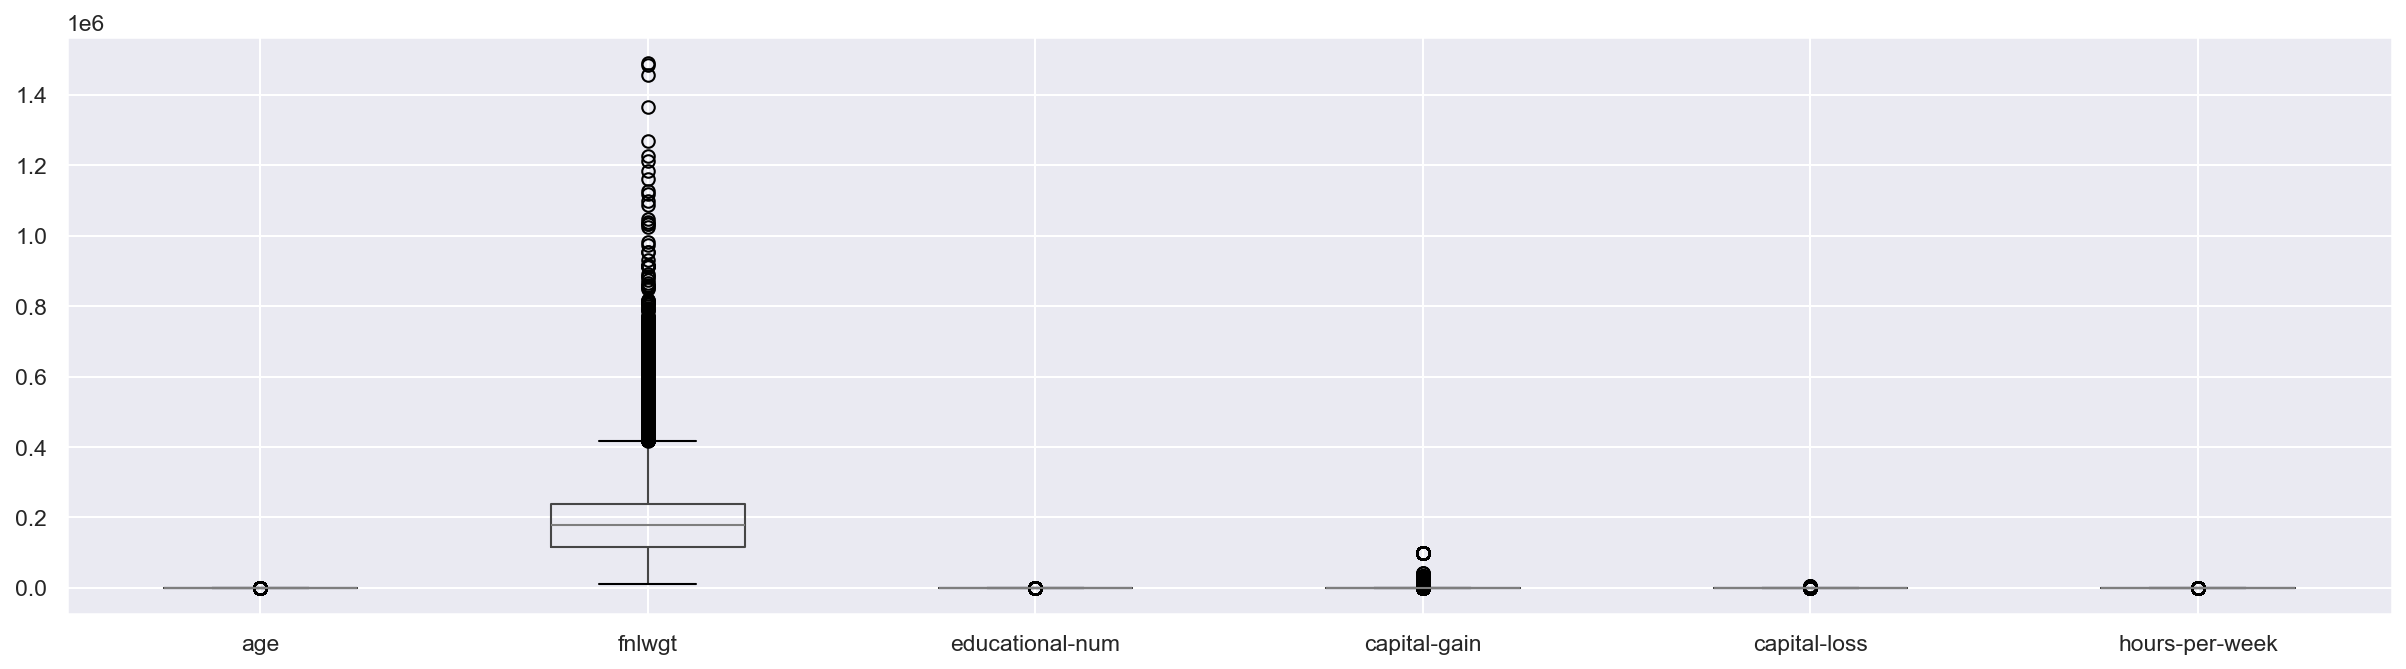

In [34]:
plt.figure(figsize=(20,5))
df.boxplot()  # plt.show()

<Axes: xlabel='age'>

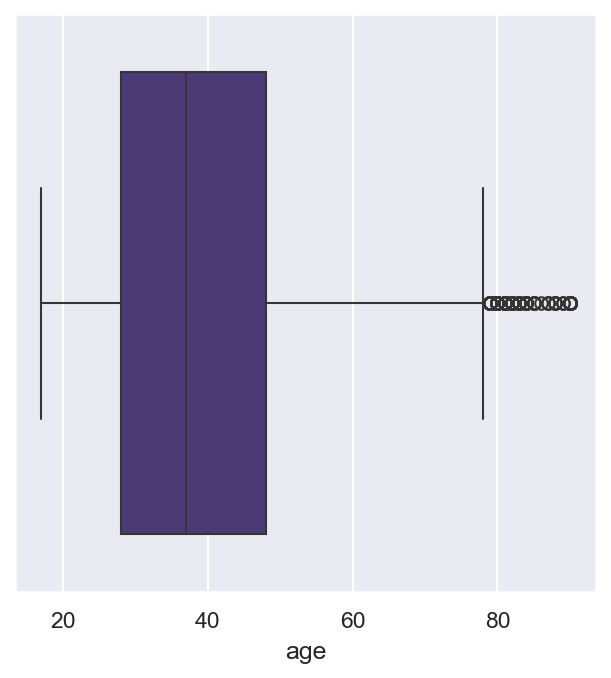

In [35]:
sns.boxplot(x=df["age"])

In [36]:
x=np.array([-7,-59,-10,2,1,1,1,1,1,6,67,89,100,40])
x

array([ -7, -59, -10,   2,   1,   1,   1,   1,   1,   6,  67,  89, 100,
        40])

In [37]:
np.clip(x,1,10)

array([ 1,  1,  1,  2,  1,  1,  1,  1,  1,  6, 10, 10, 10, 10])

In [38]:
df["age"].quantile(0.25)

np.float64(28.0)

In [39]:
df["age"].quantile(0.75)

np.float64(48.0)

In [40]:
num_cols=df.select_dtypes([int,float]).columns

In [41]:
num_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [42]:

def capping(df,cols):
    for i in cols:
        q1=df[i].quantile(0.25)
        q3=df[i].quantile(0.75)
        iqr=q3-q1
        lower=q1-(1.5*iqr)
        upper=q3+(1.5*iqr)
        df[i]=np.clip(df[i],lower,upper)

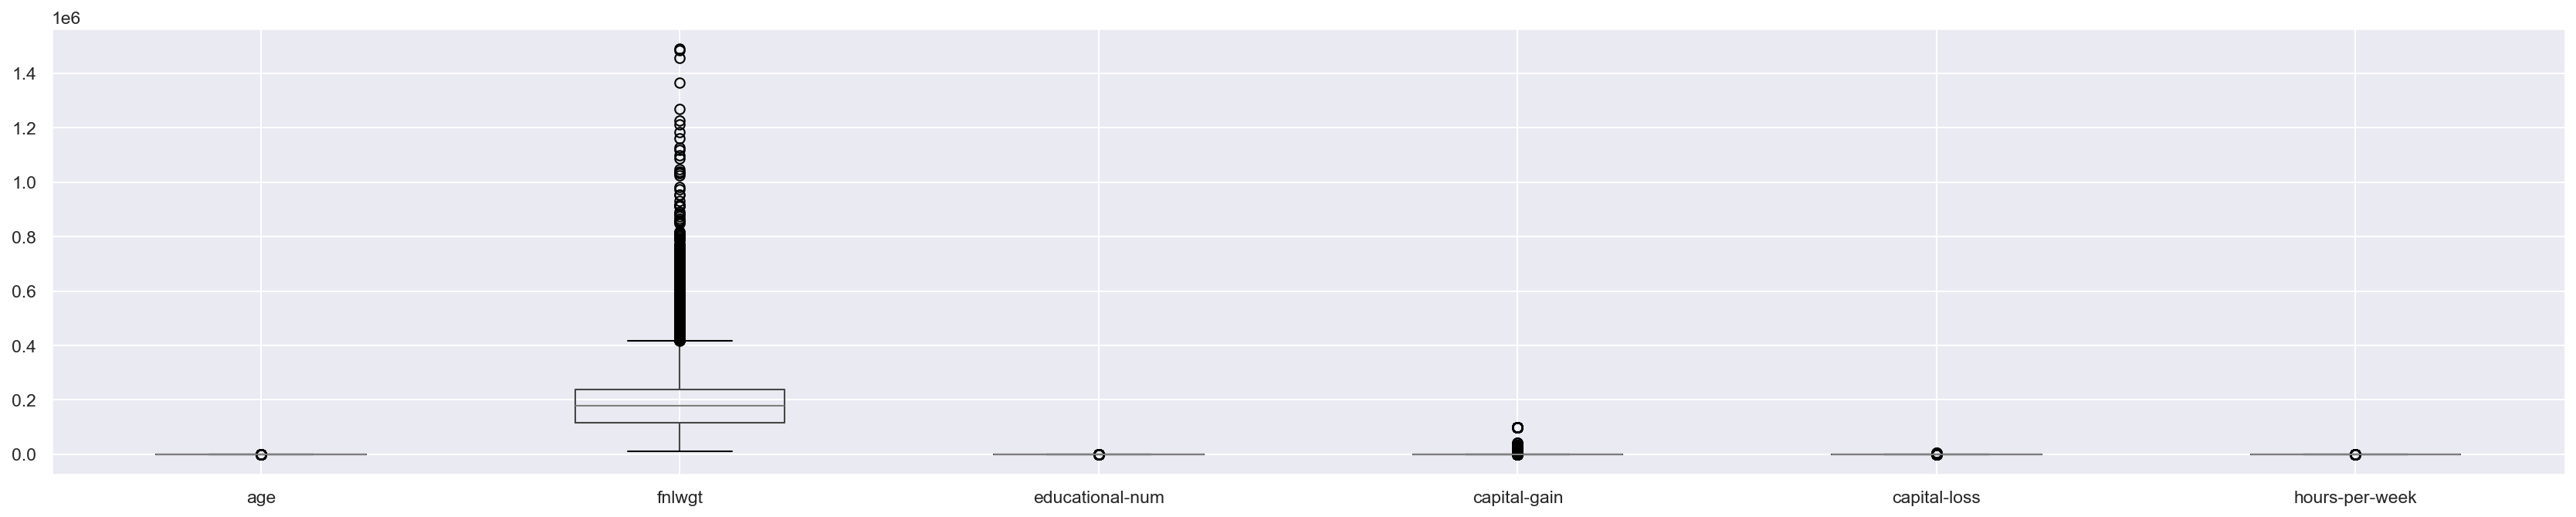

In [43]:
plt.figure(figsize=(28,5))
df.boxplot()
plt.show()

In [44]:
 # 'capping(df,num_cols)

# outliers are replaced - by capping 

In [45]:
df.shape

(47874, 15)

In [46]:
#plt.figure(figsize=(20,5))
#df.boxplot()
#plt.show()

In [47]:
df.shape

(47874, 15)

# Data Visualization

# Univariate analysis


In [48]:
df

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27.0,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40.0,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58.0,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22.0,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [49]:
text_cols=df.select_dtypes(object)
numerial_cols=df.select_dtypes([int,float])

In [50]:
text_cols.head()

,workclass,education,marital-status,occupation,relationship,race,gender,native-country,income
0,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,United-States,<=50K
1,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,United-States,<=50K
2,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,United-States,>50K
3,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,United-States,>50K
4,Private,Some-college,Never-married,Craft-repair,Own-child,White,Female,United-States,<=50K


In [51]:
for i in text_cols.columns:
    print(f"Column name:{i}")
    print(f"number of unique values {text_cols[i].nunique()}")
    print(f"unique values:{text_cols[i].unique()}")
    print("-"*100)

Column name:workclass
number of unique values 8
unique values:['Private' 'Local-gov' 'Self-emp-not-inc' 'State-gov' 'Self-emp-inc'
 'Federal-gov' 'Without-pay' 'Never-worked']
----------------------------------------------------------------------------------------------------
Column name:education
number of unique values 16
unique values:['11th' 'HS-grad' 'Assoc-acdm' 'Some-college' 'Prof-school' '7th-8th'
 'Masters' 'Bachelors' '5th-6th' '10th' 'Assoc-voc' '9th' 'Doctorate'
 '12th' '1st-4th' 'Preschool']
----------------------------------------------------------------------------------------------------
Column name:marital-status
number of unique values 7
unique values:['Never-married' 'Married-civ-spouse' 'Widowed' 'Divorced' 'Separated'
 'Married-spouse-absent' 'Married-AF-spouse']
----------------------------------------------------------------------------------------------------
Column name:occupation
number of unique values 14
unique values:['Machine-op-inspct' 'Farming-fishing' 

# Bar plot on text based columns

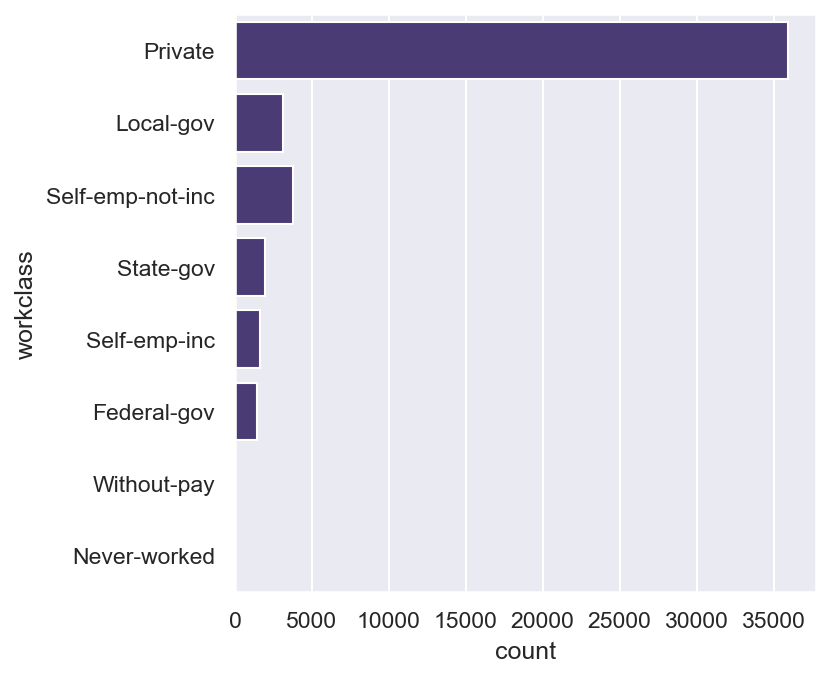

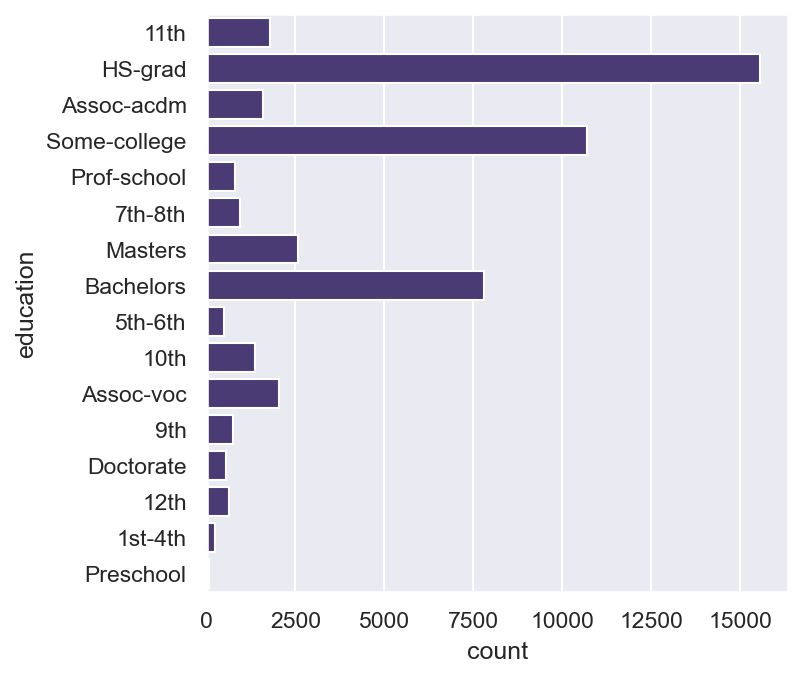

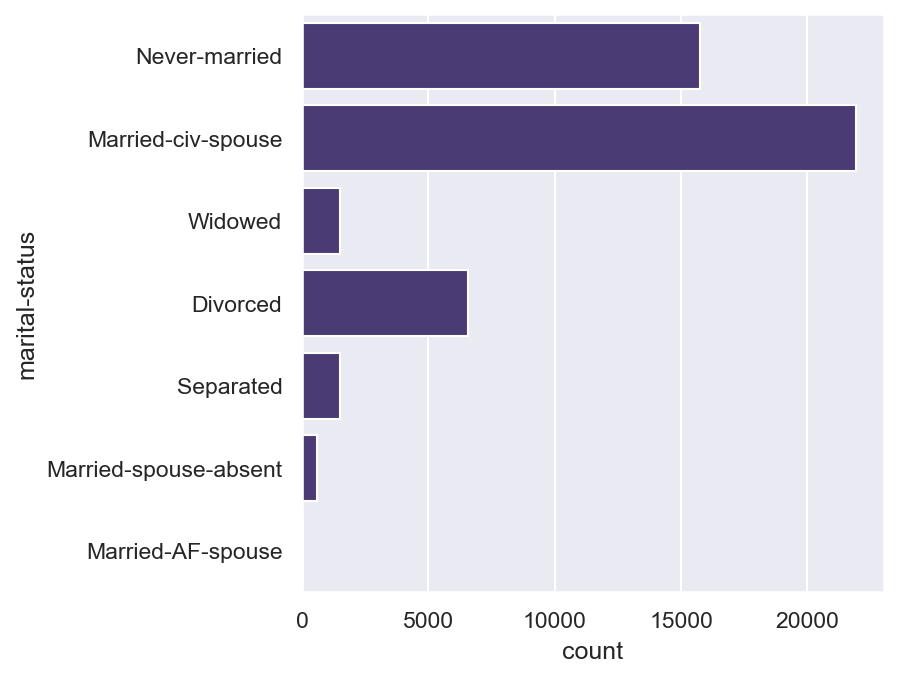

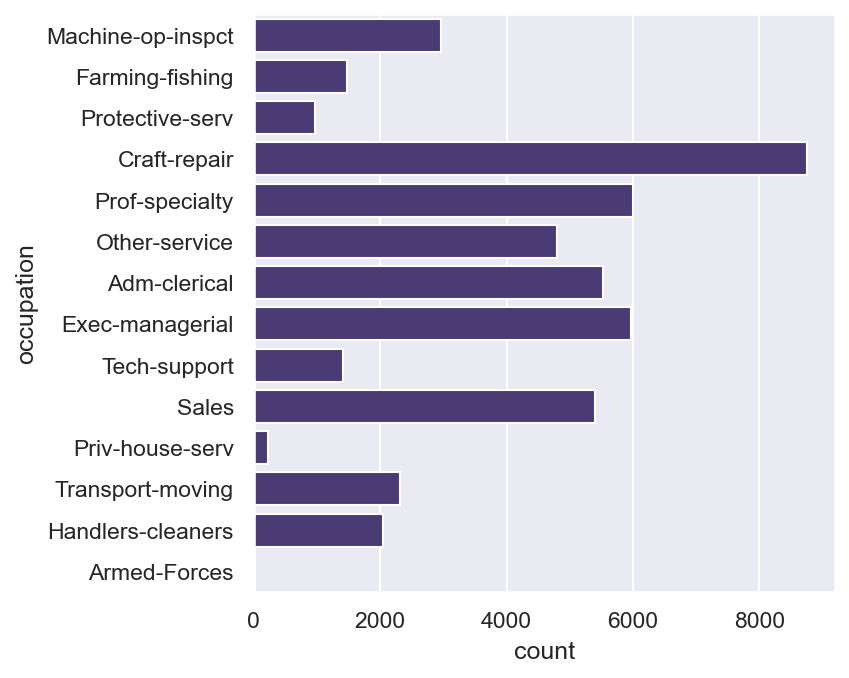

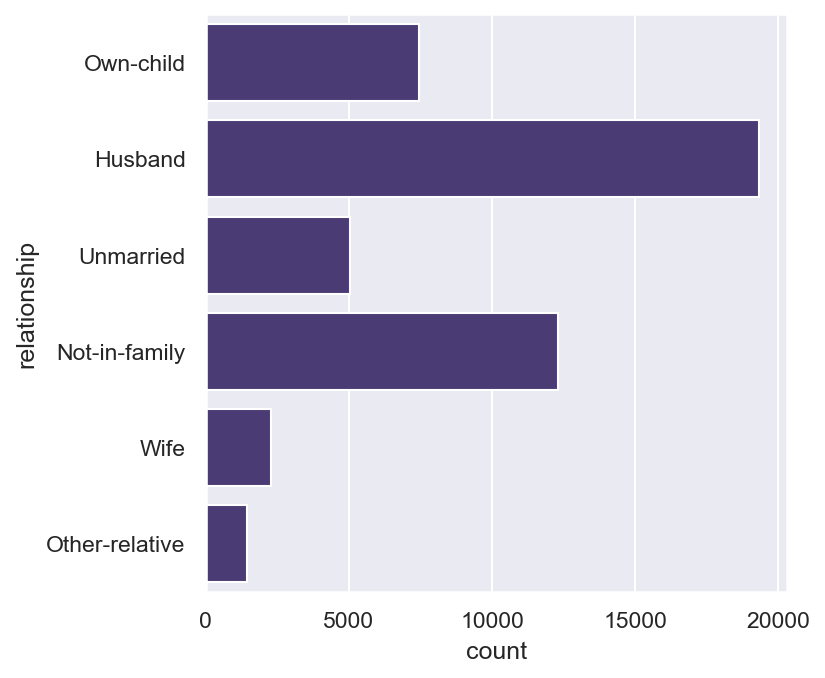

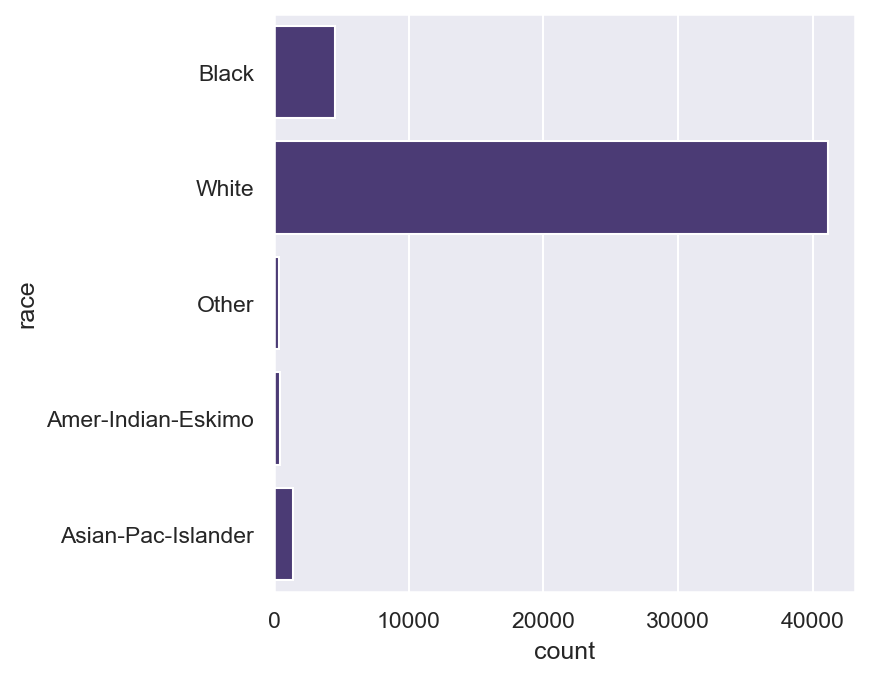

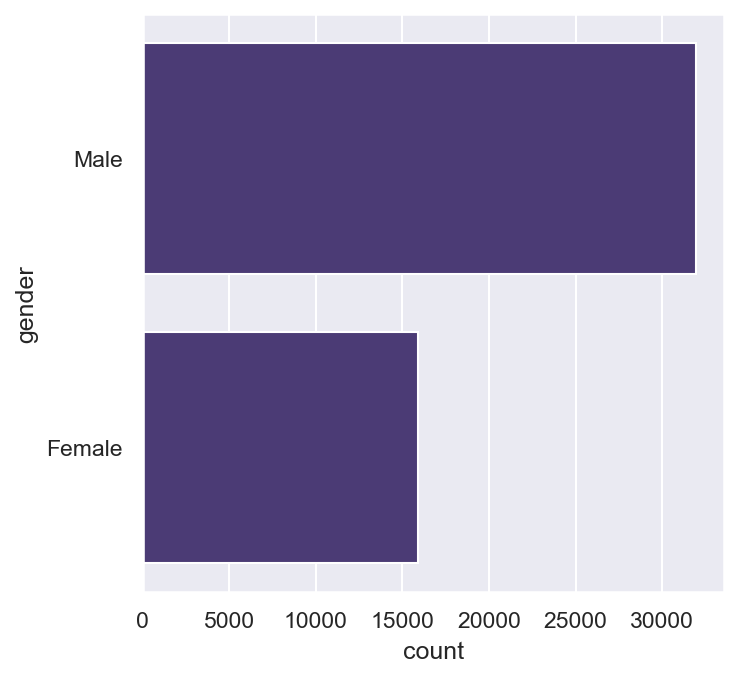

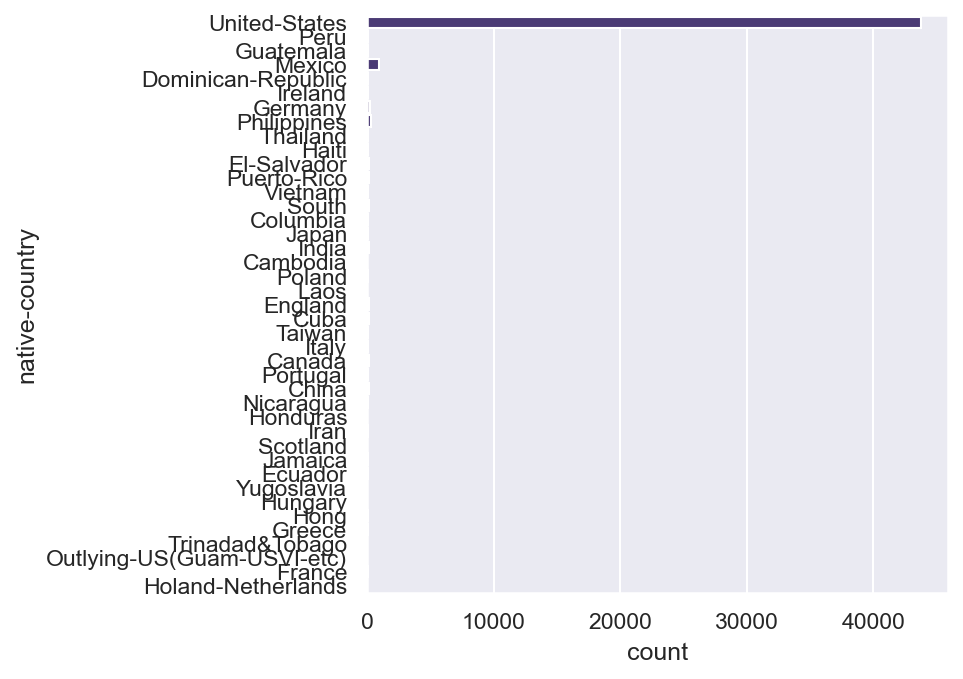

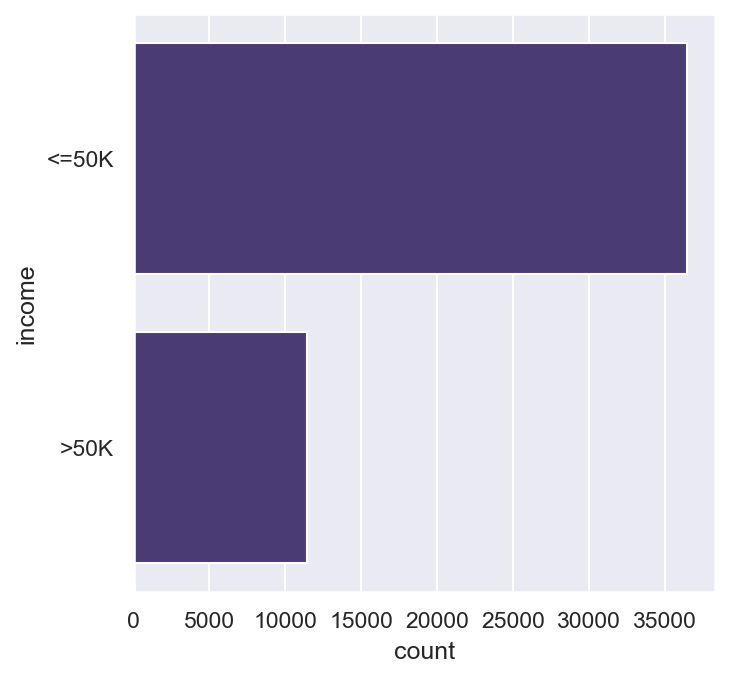

In [52]:
for i in text_cols.columns:
    sns.countplot(y=text_cols[i])
    plt.show()

# HISTOGRAM for numeriacal column


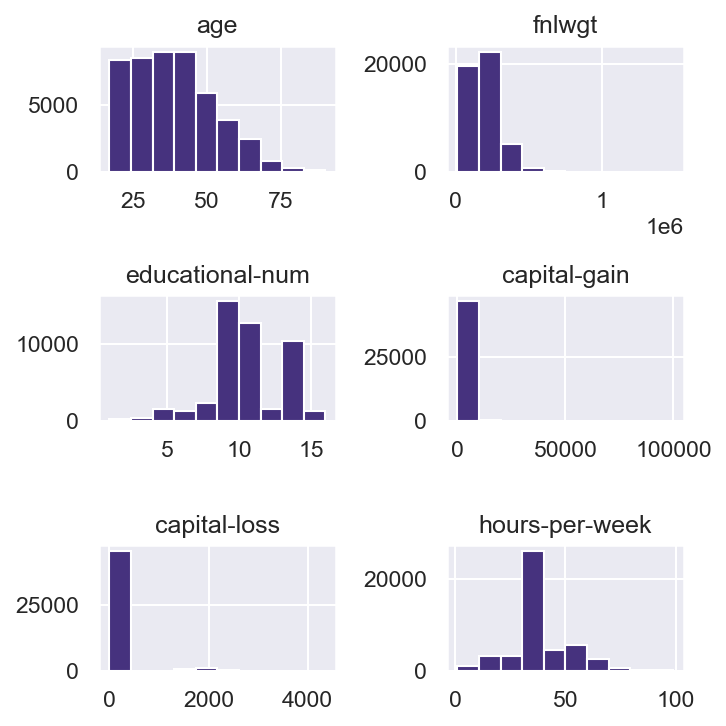

In [53]:
numerial_cols.hist()
plt.tight_layout()

# change fontstyle of 2 columns

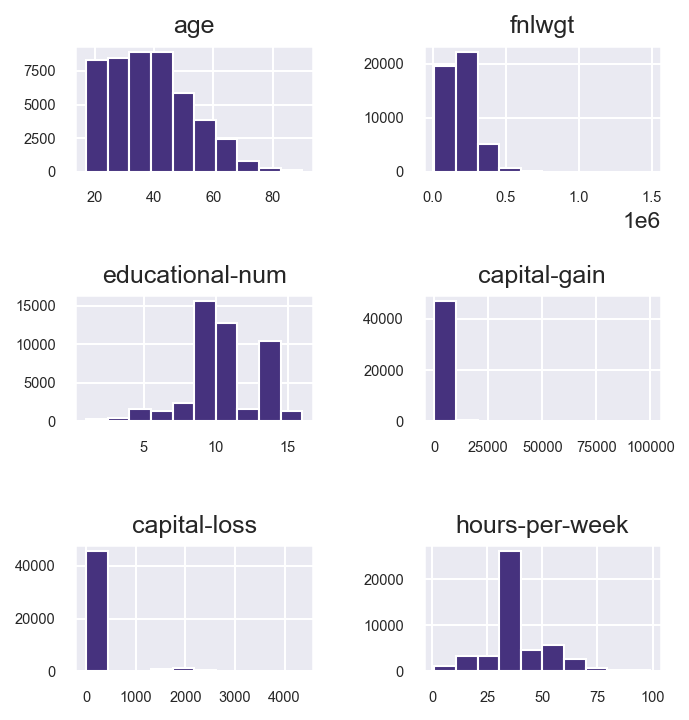

In [54]:
 # store histograms in vaiable   these histograams are in 2D structure 
# to change fontstyle make in 1D
histogram=numerial_cols.hist()
plt.tight_layout()

for i in histogram.flatten():
    i.tick_params(axis="both",labelsize=7)  # axis = both,single
    # i.set_title(i.get_xlabel(),fontsize=10)

# if there is single column

(array([    0.,  5000., 10000., 15000., 20000., 25000., 30000., 35000.]),
 [Text(0, 0.0, '0'),
  Text(0, 5000.0, '5000'),
  Text(0, 10000.0, '10000'),
  Text(0, 15000.0, '15000'),
  Text(0, 20000.0, '20000'),
  Text(0, 25000.0, '25000'),
  Text(0, 30000.0, '30000'),
  Text(0, 35000.0, '35000')])

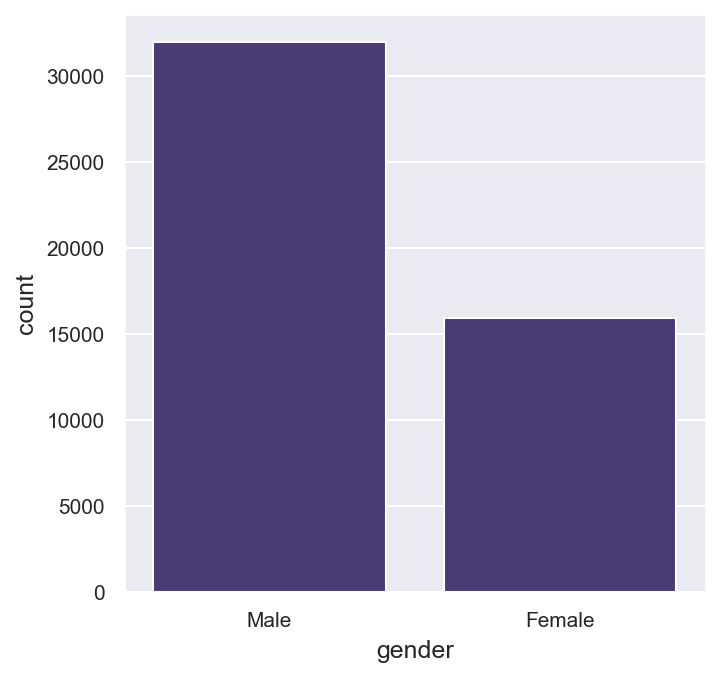

In [55]:
sns.countplot(x=df["gender"])
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# plt.show()

# By variate Analysis (Two variables)
- use scatter plot for numerical vs non- numerical

# Pandas Function

In [56]:
data=pd.DataFrame({
    "City":["pune","Mumbai","pune","Goa"],
    "year":[2023,2024,2025,2023],
    "sales":[122,200,110,300]
})

In [57]:
data

,City,year,sales
0,pune,2023,122
1,Mumbai,2024,200
2,pune,2025,110
3,Goa,2023,300


In [58]:
data.set_index(["City","year"],inplace=True)

In [59]:
data

,,sales
City,year,
pune,2023,122
Mumbai,2024,200
pune,2025,110
Goa,2023,300


In [60]:
# pivote like structure
data.unstack()

sales              
year     2023   2024   2025
City                       
Goa     300.0    NaN    NaN
Mumbai    NaN  200.0    NaN
pune    122.0    NaN  110.0

In [61]:
data.unstack(level="City")  # unstack is usefull to create a table per our convinieance to visualize graph

sales              
City    Goa Mumbai   pune
year                     
2023  300.0    NaN  122.0
2024    NaN  200.0    NaN
2025    NaN    NaN  110.0

In [62]:
data=pd.DataFrame({
    "Gender":["Male","Female","Female","Male"],
    "Pass":["Yes","No","Yes","Yes"],
    "Score":[60,35,95,90]
})

In [63]:
data

,Gender,Pass,Score
0,Male,Yes,60
1,Female,No,35
2,Female,Yes,95
3,Male,Yes,90


In [64]:
# check the overall result columns data wise   # pandas function
pd.crosstab(data["Gender"],data["Pass"])

Pass,No,Yes
Gender,,
Female,1,1
Male,0,2


In [65]:
pd.crosstab(data["Gender"],data["Pass"],data["Score"],aggfunc="mean")

Pass,No,Yes
Gender,,
Female,35.0,95.0
Male,NaN,75.0


In [66]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K


# How Does Education column affect Income

In [67]:
df.groupby(["education","income"]).size()

education     income
10th          <=50K      1284
              >50K         86
11th          <=50K      1707
              >50K         90
12th          <=50K       587
              >50K         45
1st-4th       <=50K       230
              >50K          8
5th-6th       <=50K       463
              >50K         24
7th-8th       <=50K       871
              >50K         59
9th           <=50K       706
              >50K         39
Assoc-acdm    <=50K      1171
              >50K        406
Assoc-voc     <=50K      1517
              >50K        516
Bachelors     <=50K      4565
              >50K       3228
Doctorate     <=50K       151
              >50K        410
HS-grad       <=50K     13080
              >50K       2477
Masters       <=50K      1156
              >50K       1421
Preschool     <=50K        79
              >50K          1
Prof-school   <=50K       205
              >50K        603
Some-college  <=50K      8659
              >50K       2030
dtype: int64

In [68]:
ed_imp=df.groupby(["education","income"]).size().unstack()  # plot the graph

In [69]:
ed_imp

income,<=50K,>50K
education,,
10th,1284,86
11th,1707,90
12th,587,45
1st-4th,230,8
5th-6th,463,24
7th-8th,871,59
9th,706,39
Assoc-acdm,1171,406
Assoc-voc,1517,516


<Axes: xlabel='education'>

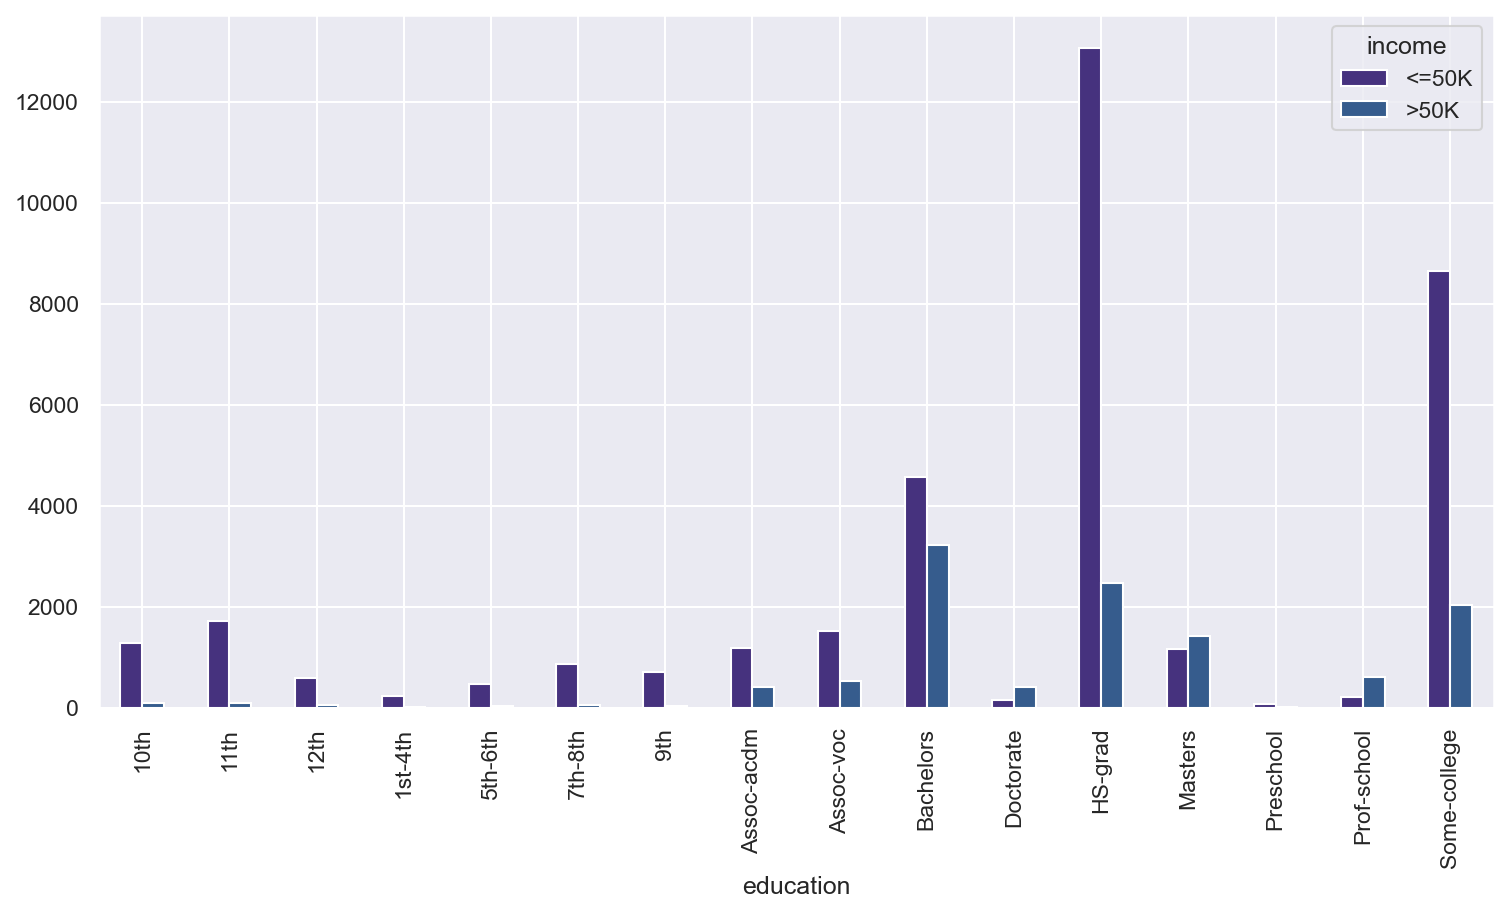

In [70]:
ed_imp.plot(kind="bar",figsize=(12,6))

- Higher education has more income

# How Does hours per Week differ for>50 and<50

<Axes: xlabel='hours-per-week'>

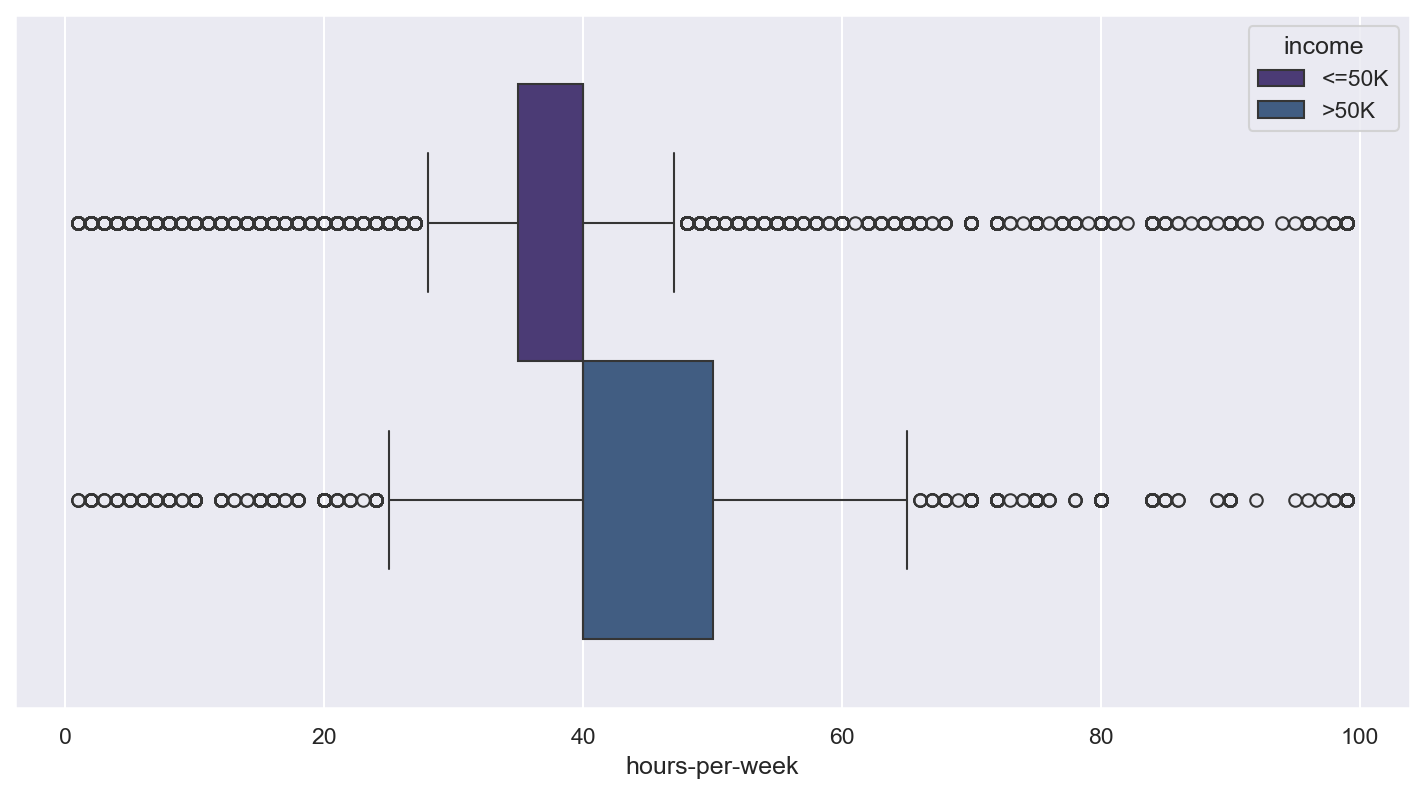

In [71]:
plt.rcParams["figure.figsize"]=(12,6)
sns.boxplot(x=df["hours-per-week"],hue=df["income"])  # hue for to add text column by income 

- people whose income is more whose working hours are more than those
- houers per week more whose income more than >50

# How does marital status affetcs income

Text(0, 0.5, 'count')

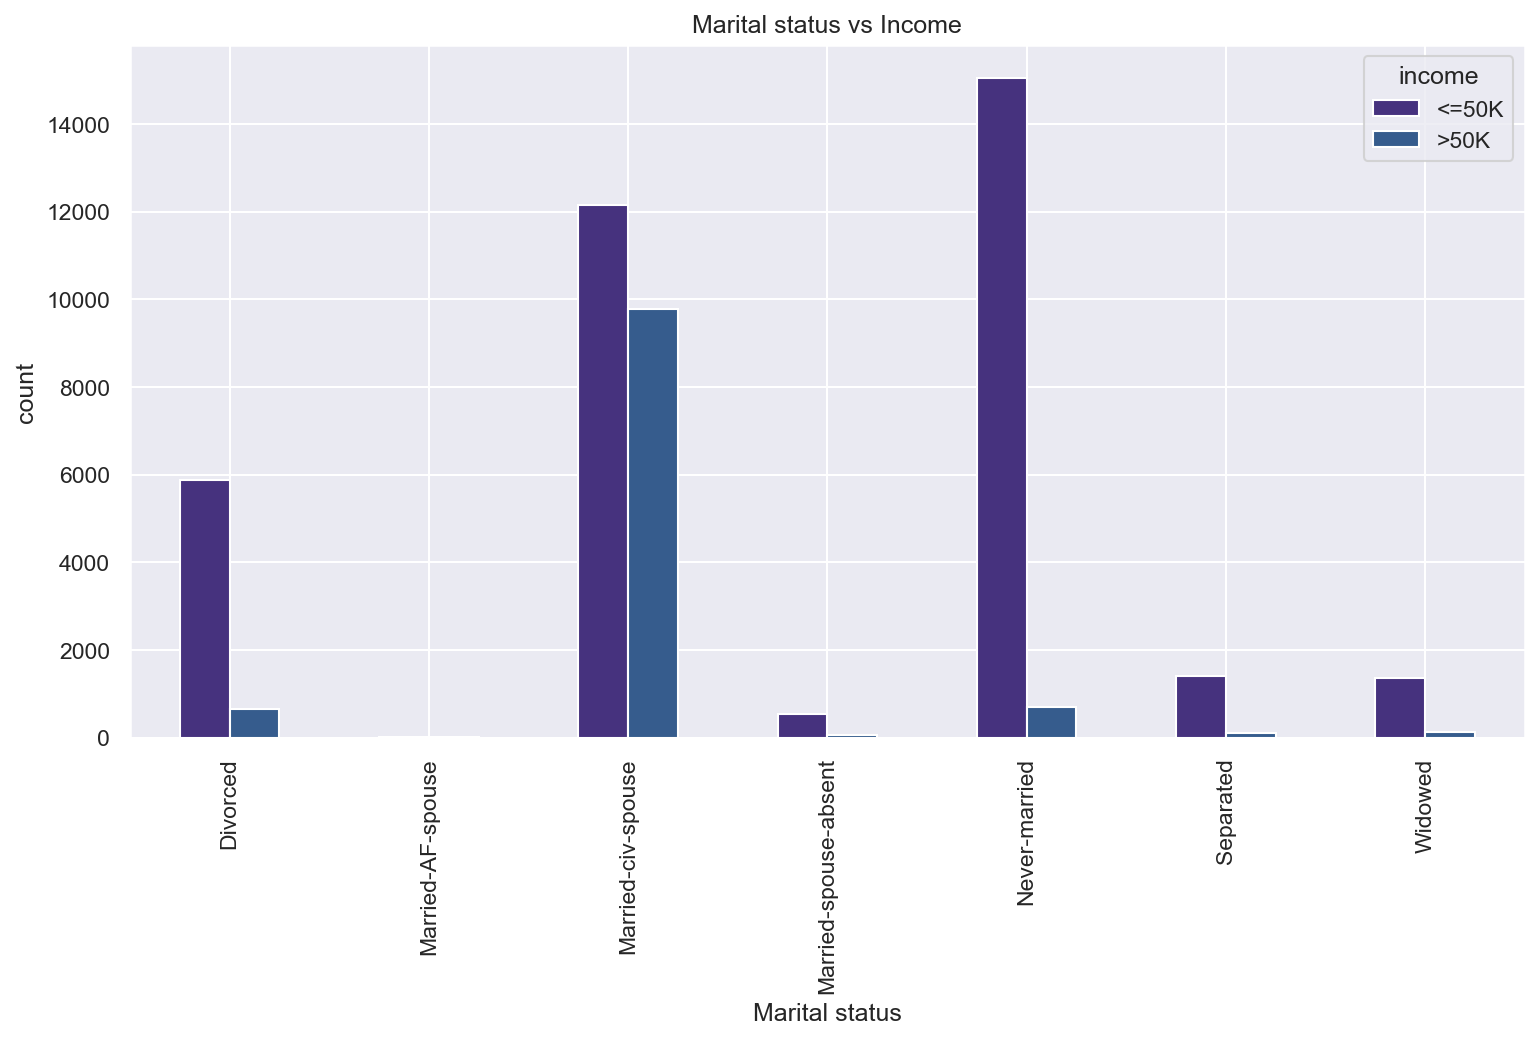

In [72]:
df.groupby(["marital-status","income"]).size().unstack().plot(kind="bar")
plt.title("Marital status vs Income")
plt.xlabel("Marital status")
plt.ylabel("count")

- married civ spouse has hihest no of people more than <50 income
- those are single,seprated,or divorced those has >50 thousand income


In [73]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K


# Does Gender impact Income

In [74]:
df.groupby(["gender","income"]).size()

gender  income
Female  <=50K     14169
        >50K       1738
Male    <=50K     22262
        >50K       9705
dtype: int64

In [75]:
df.groupby(["gender","income"]).size().unstack()

income,<=50K,>50K
gender,,
Female,14169,1738
Male,22262,9705


<Axes: xlabel='gender'>

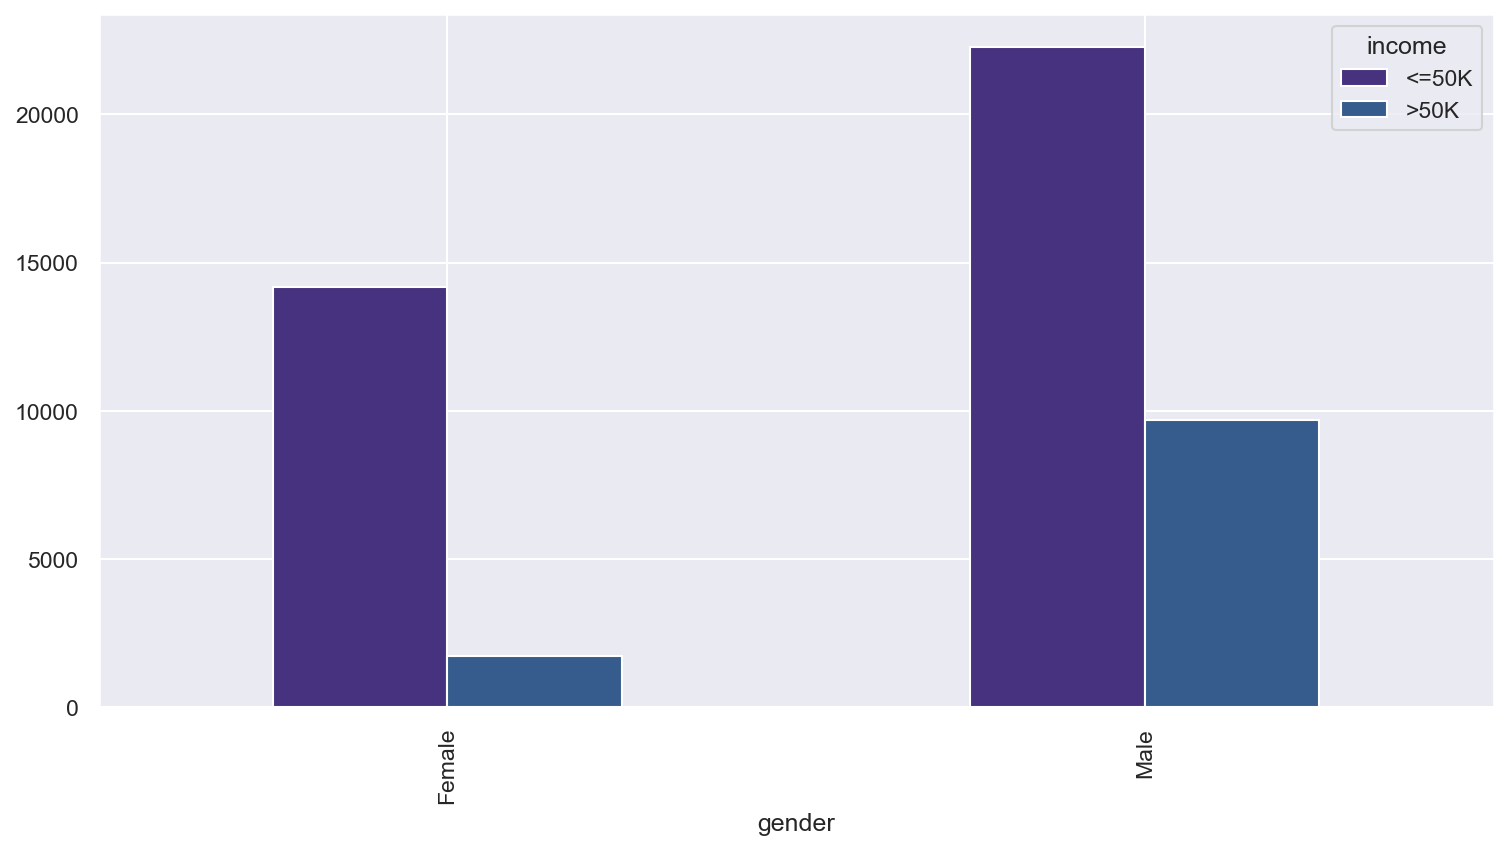

In [76]:
df.groupby(["gender","income"]).size().unstack().plot(kind="bar")

# hours of work with respect to education(income)

In [77]:
df.pivot_table(index="education",columns="income",values="hours-per-week", aggfunc="mean")

income,<=50K,>50K
education,,
10th,36.349688,45.767442
11th,33.339192,45.288889
12th,34.570698,45.866667
1st-4th,38.230435,51.000000
5th-6th,38.349892,45.375000
7th-8th,38.266361,48.627119
9th,38.019830,45.230769
Assoc-acdm,39.625107,44.524631
Assoc-voc,40.768622,44.346899


In [78]:
    df.pivot_table(index="education",columns="income",values="hours-per-week", aggfunc="mean").sort_values(by=">50K",ascending=False)

income,<=50K,>50K
education,,
1st-4th,38.230435,51.000000
Prof-school,42.658537,49.150912
7th-8th,38.266361,48.627119
Doctorate,44.331126,47.529268
12th,34.570698,45.866667
10th,36.349688,45.767442
Masters,41.071799,45.701619
5th-6th,38.349892,45.375000
Bachelors,40.454765,45.352850


# bar plot with multiple column

In [79]:
target="income"
def bar_by_income(col):
    grp=df.groupby([col,target]).size().unstack()
    grp.plot(kind="bar")
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

In [80]:
txt_col=df.select_dtypes(object).columns  # if not want any column=(object).drop(columns=["native country"]).columns
txt_col


Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

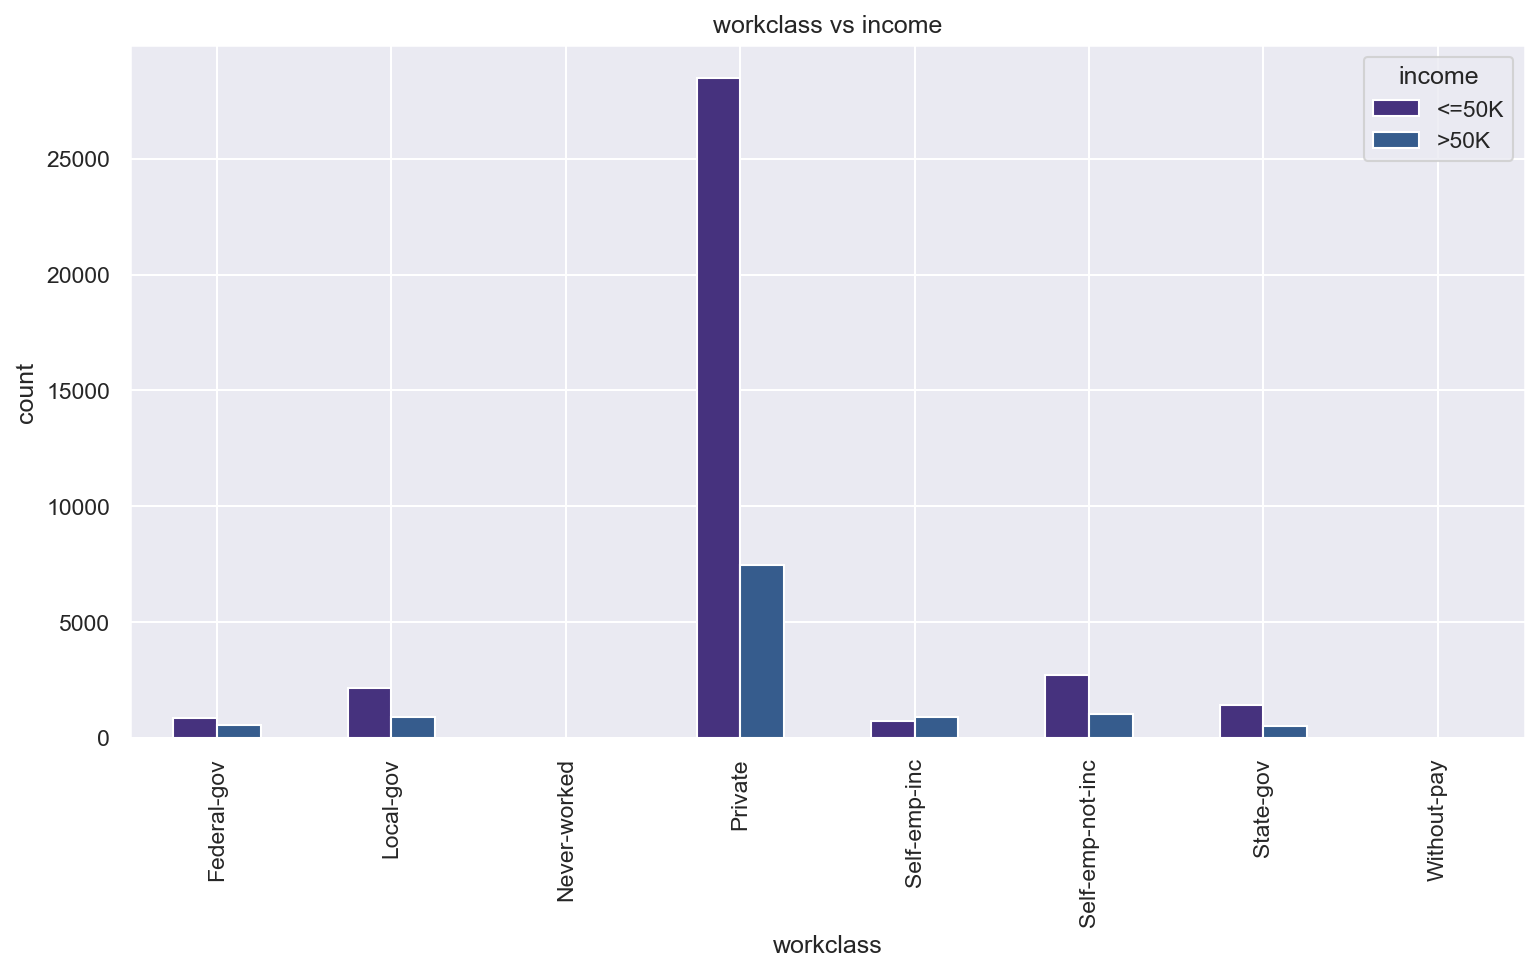

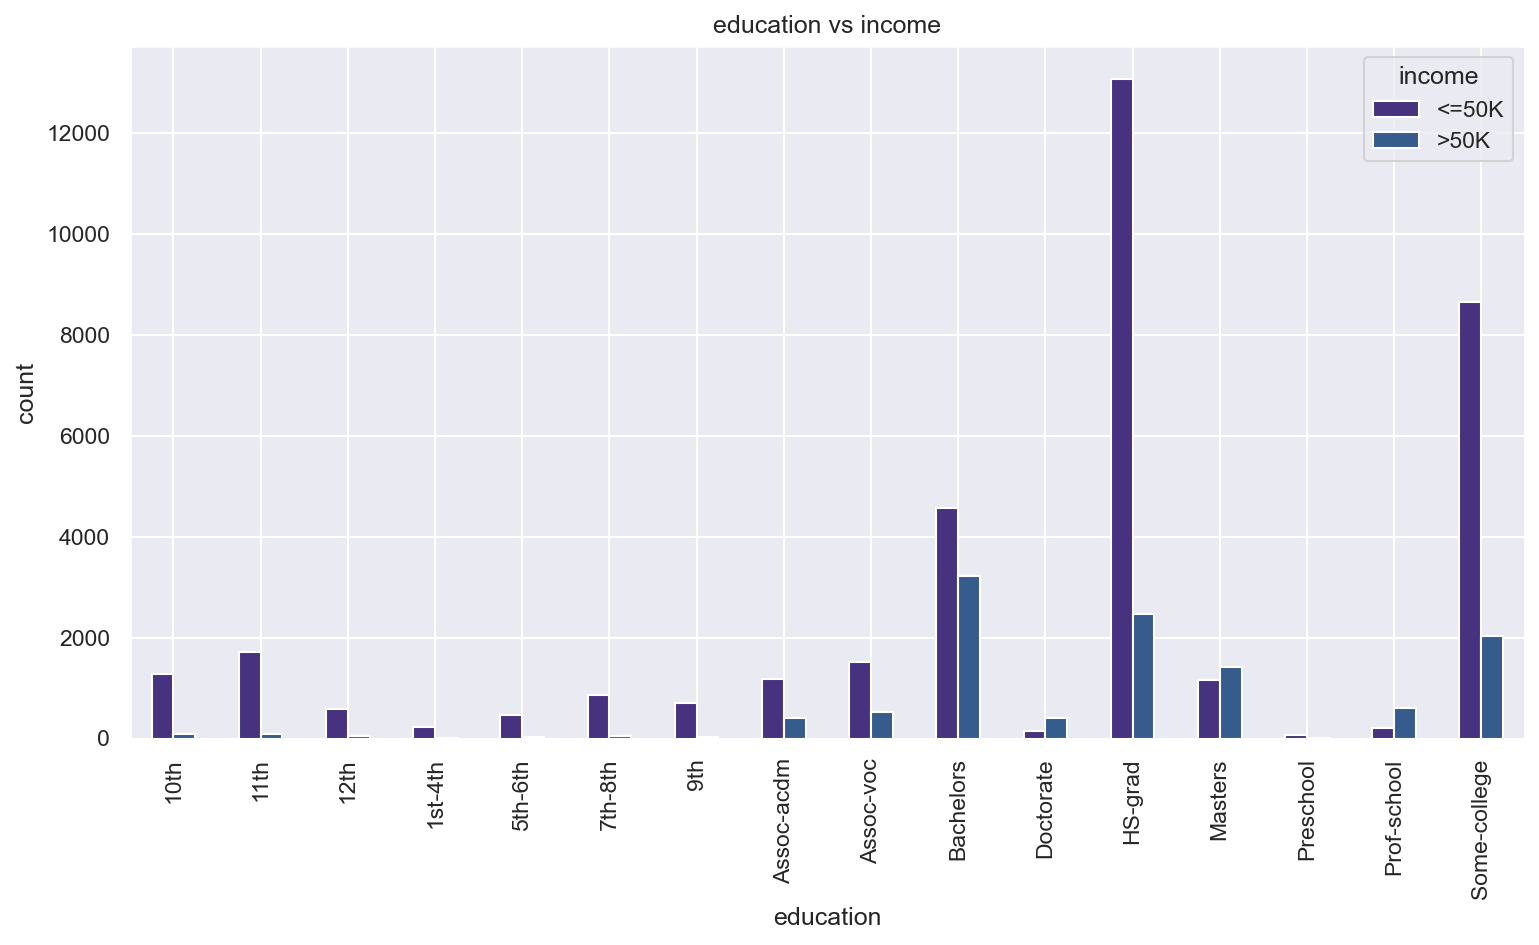

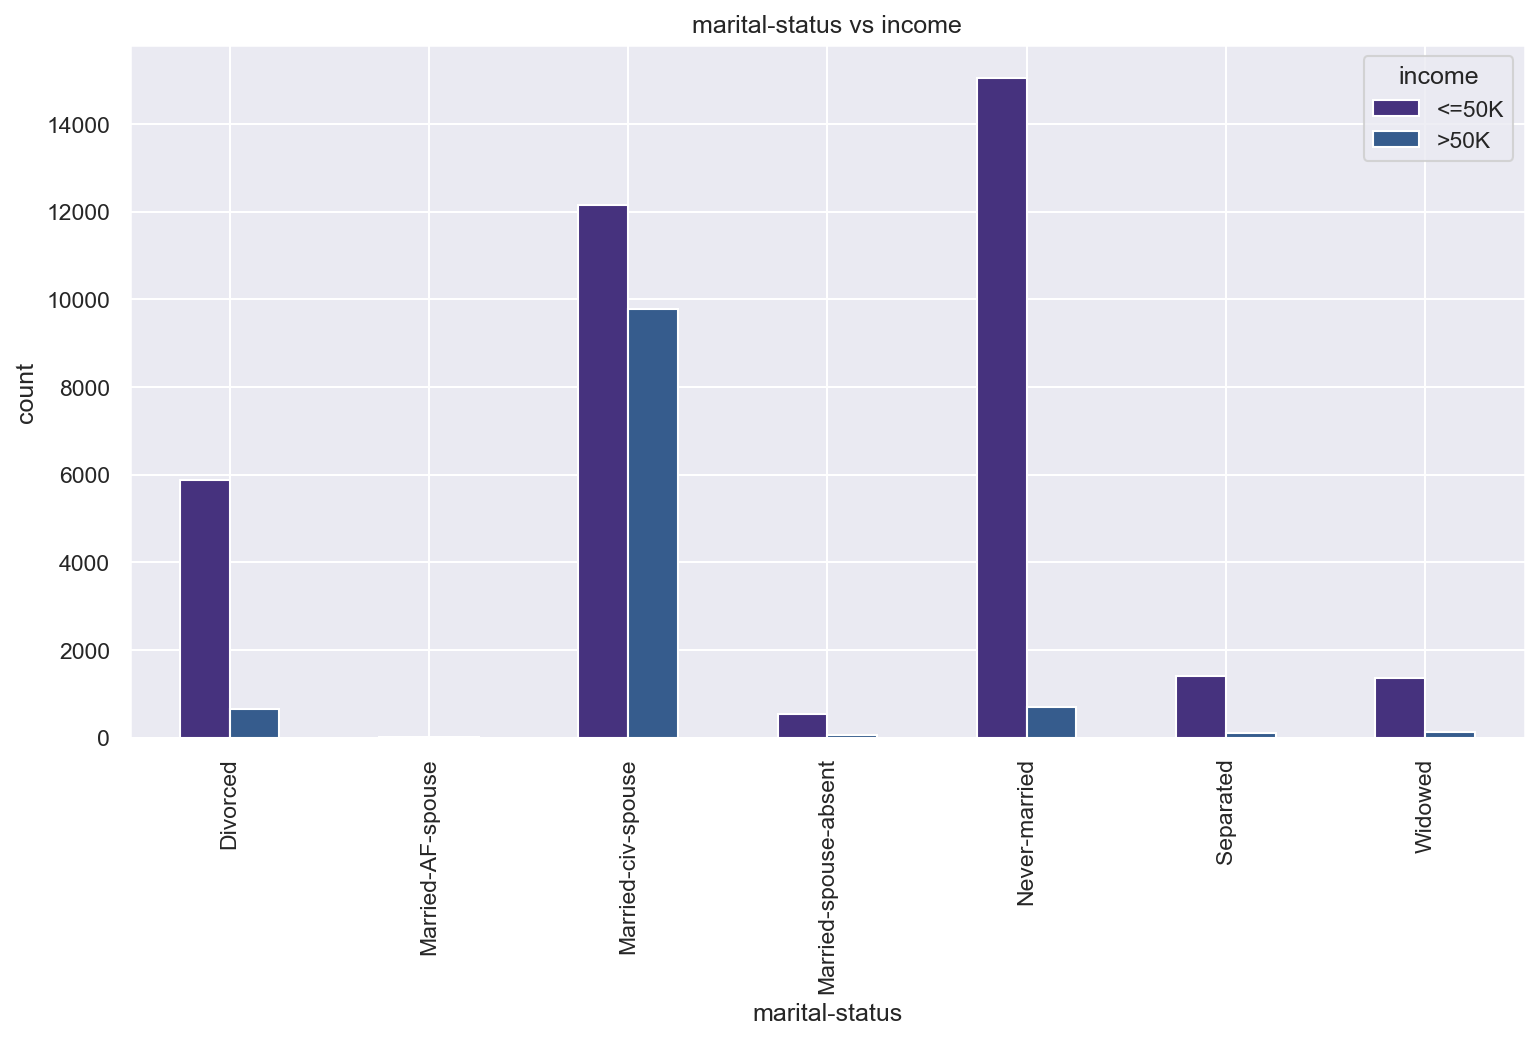

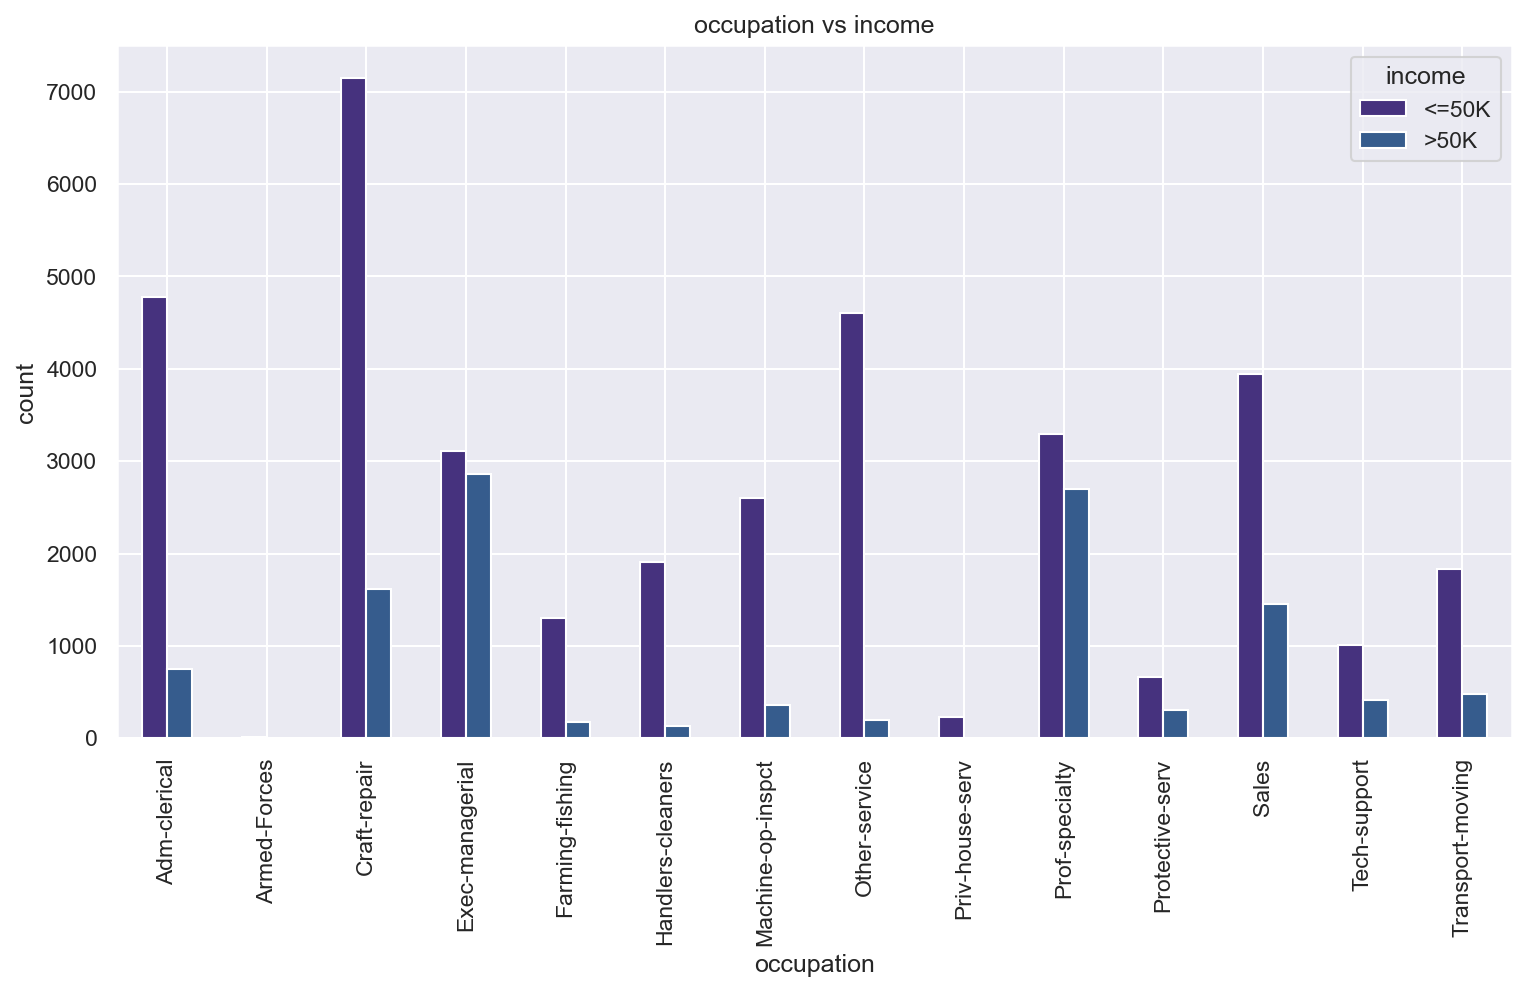

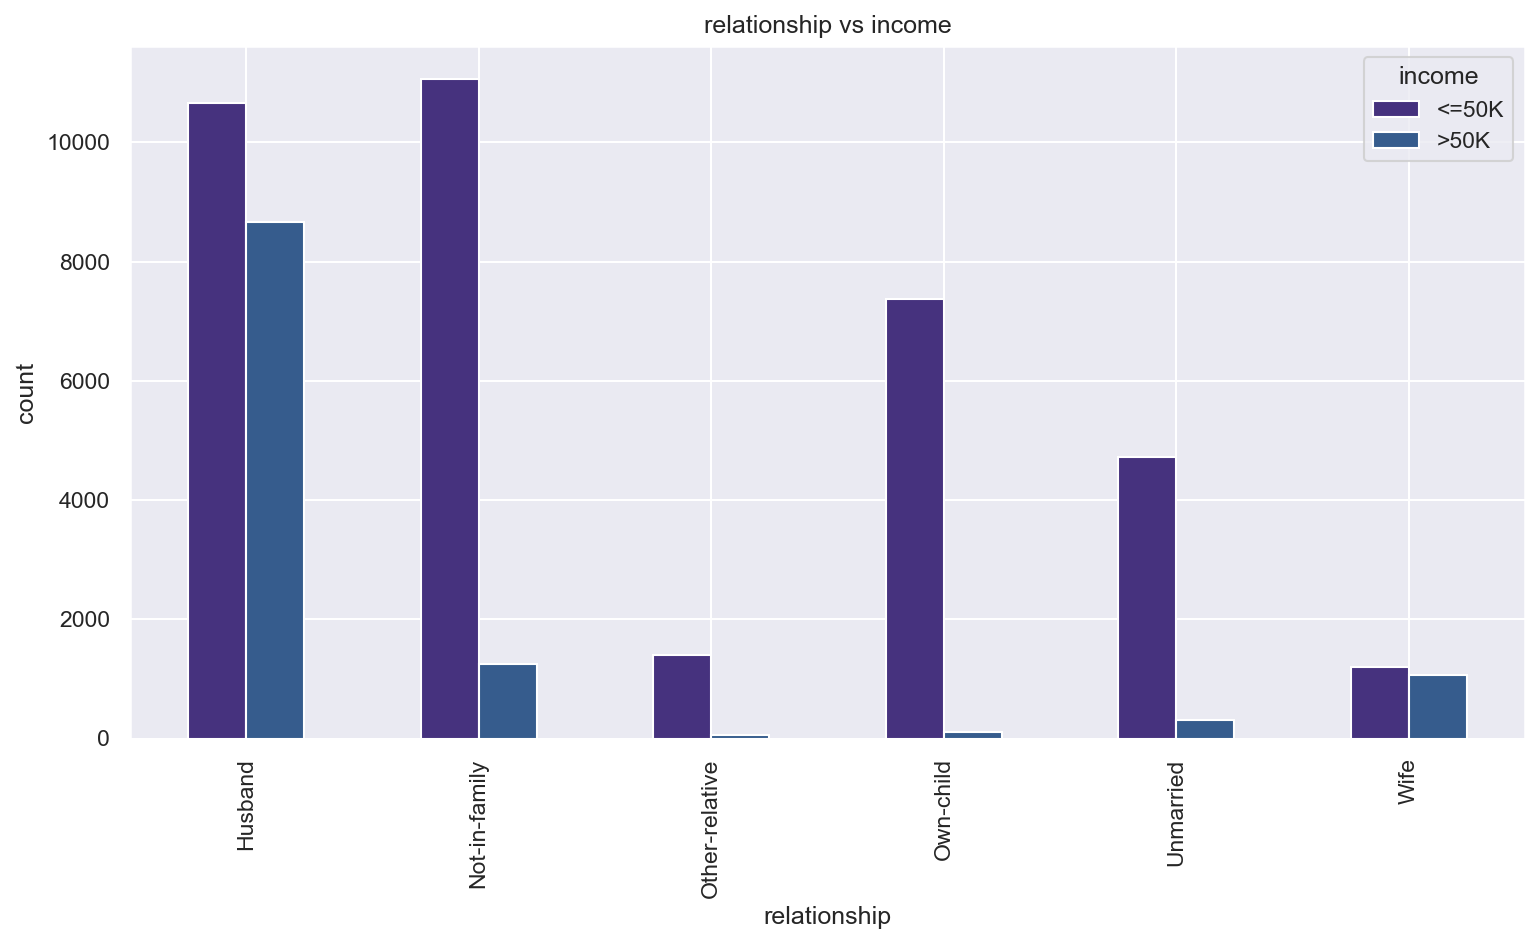

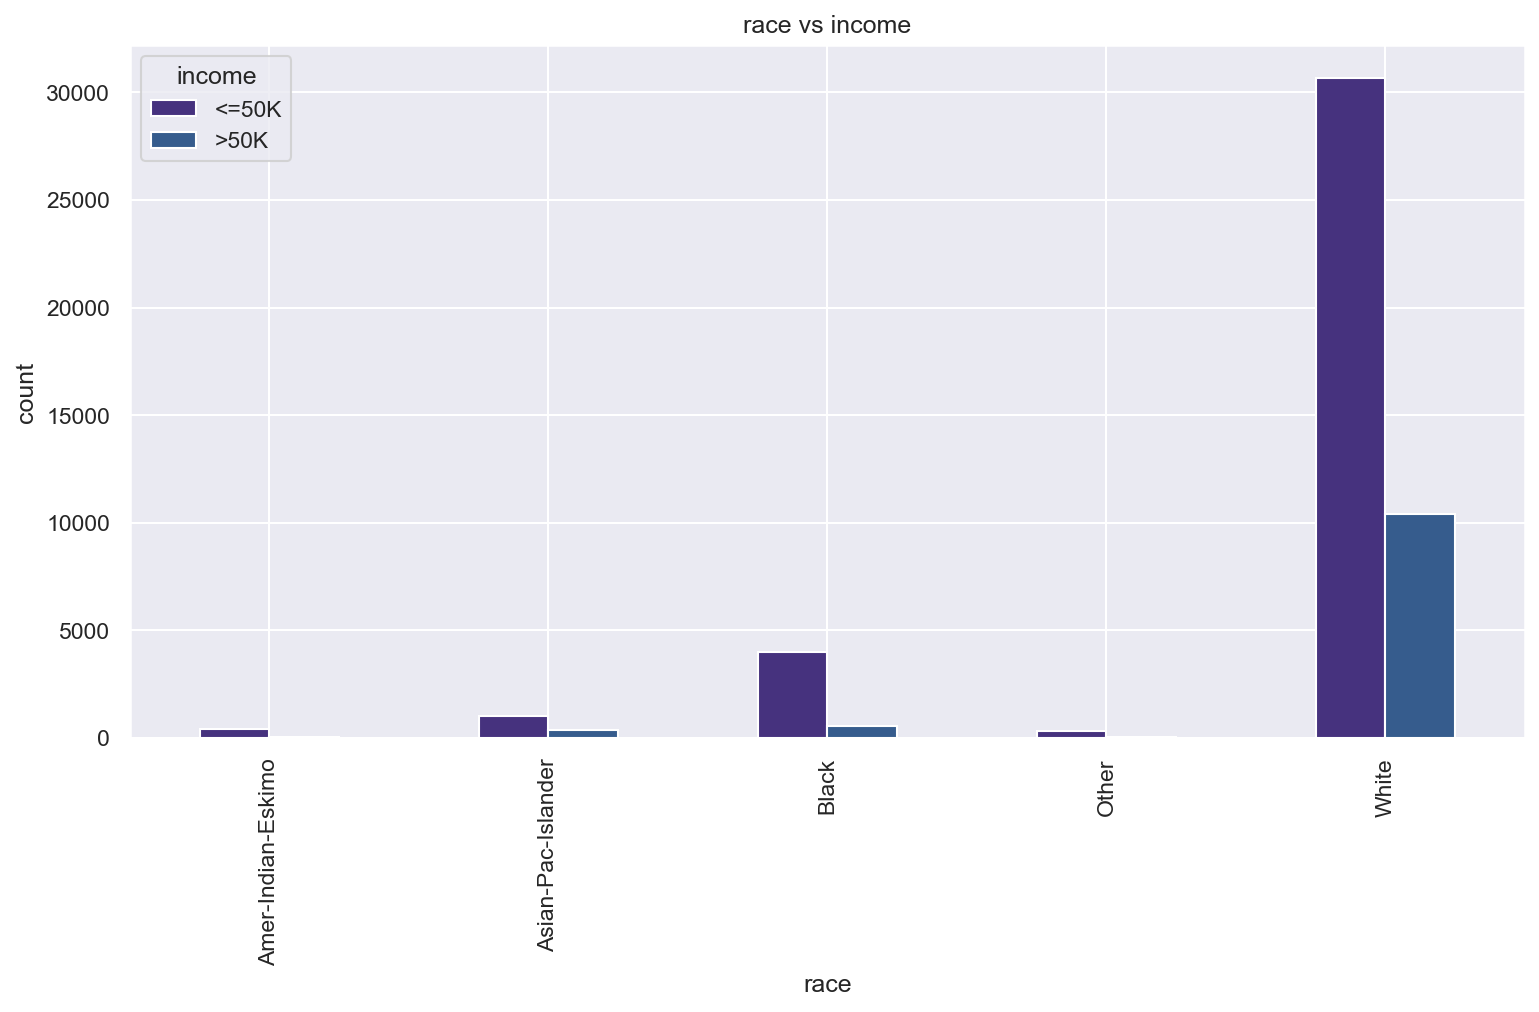

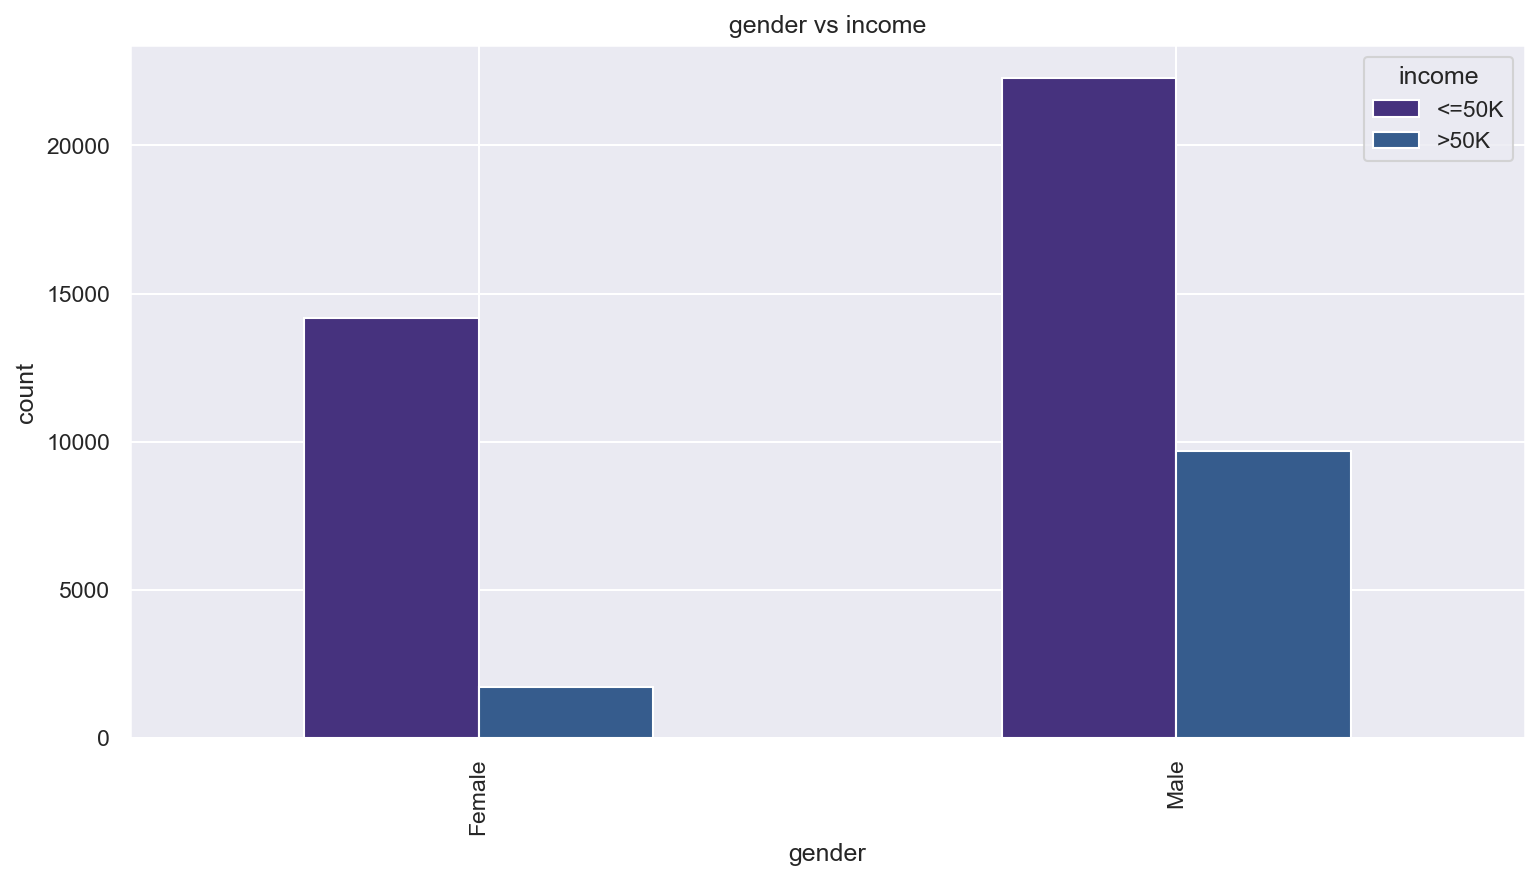

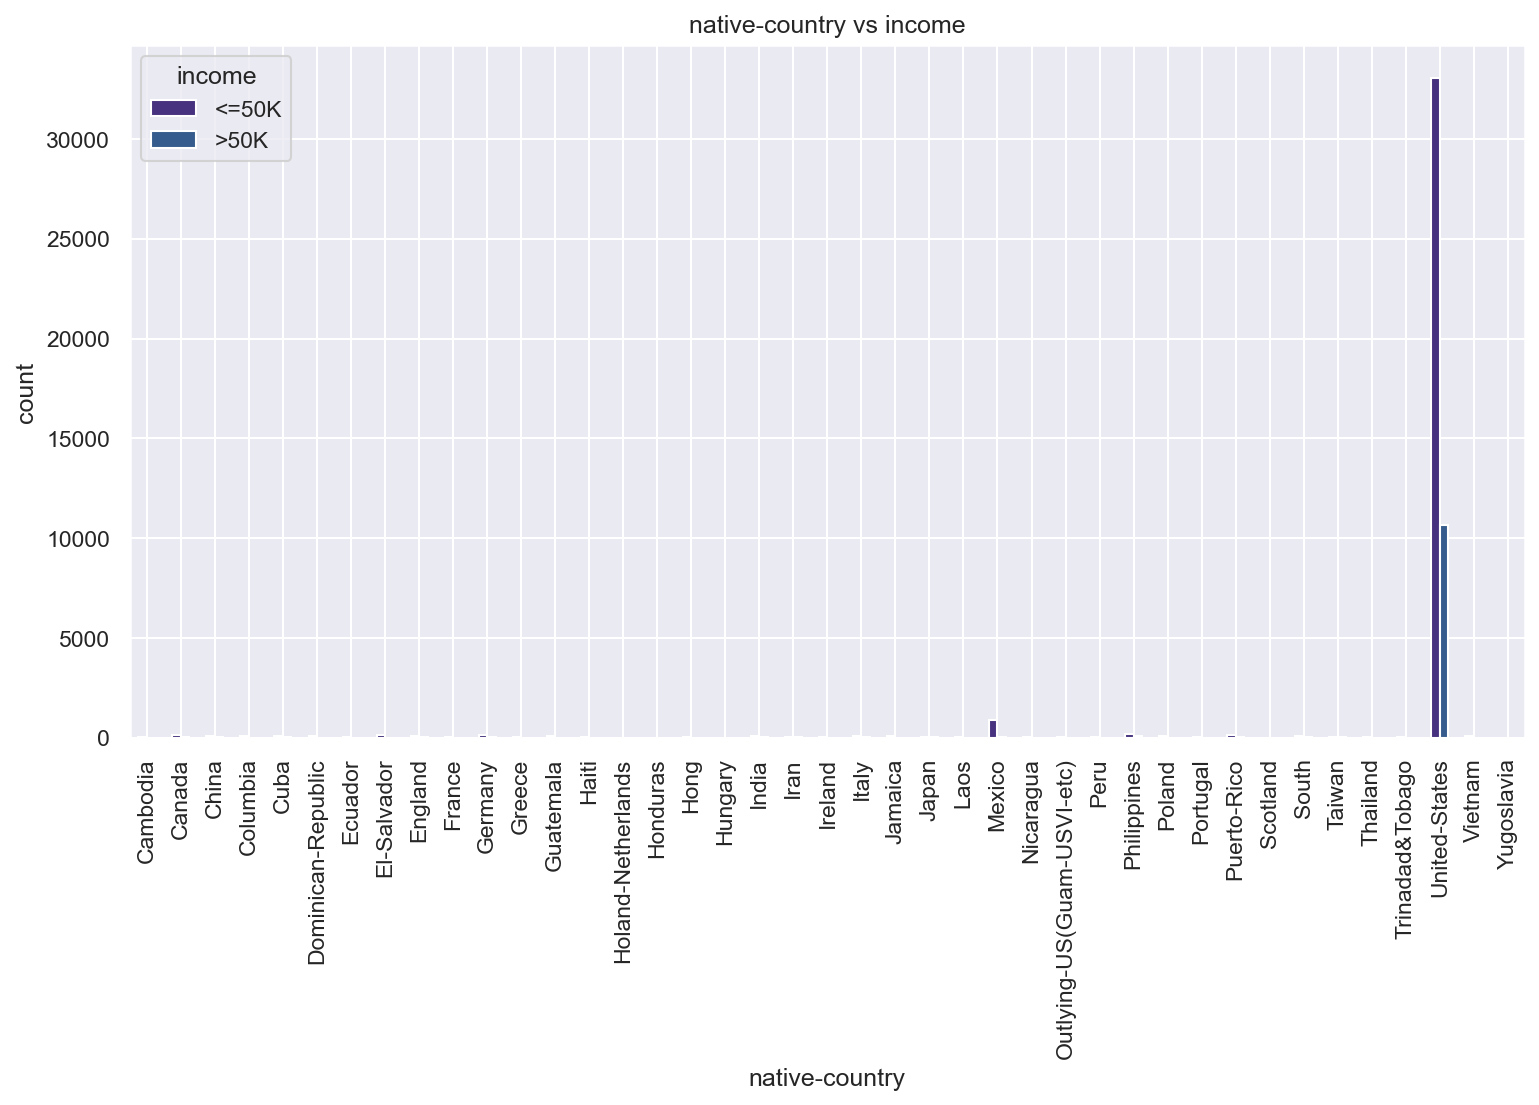

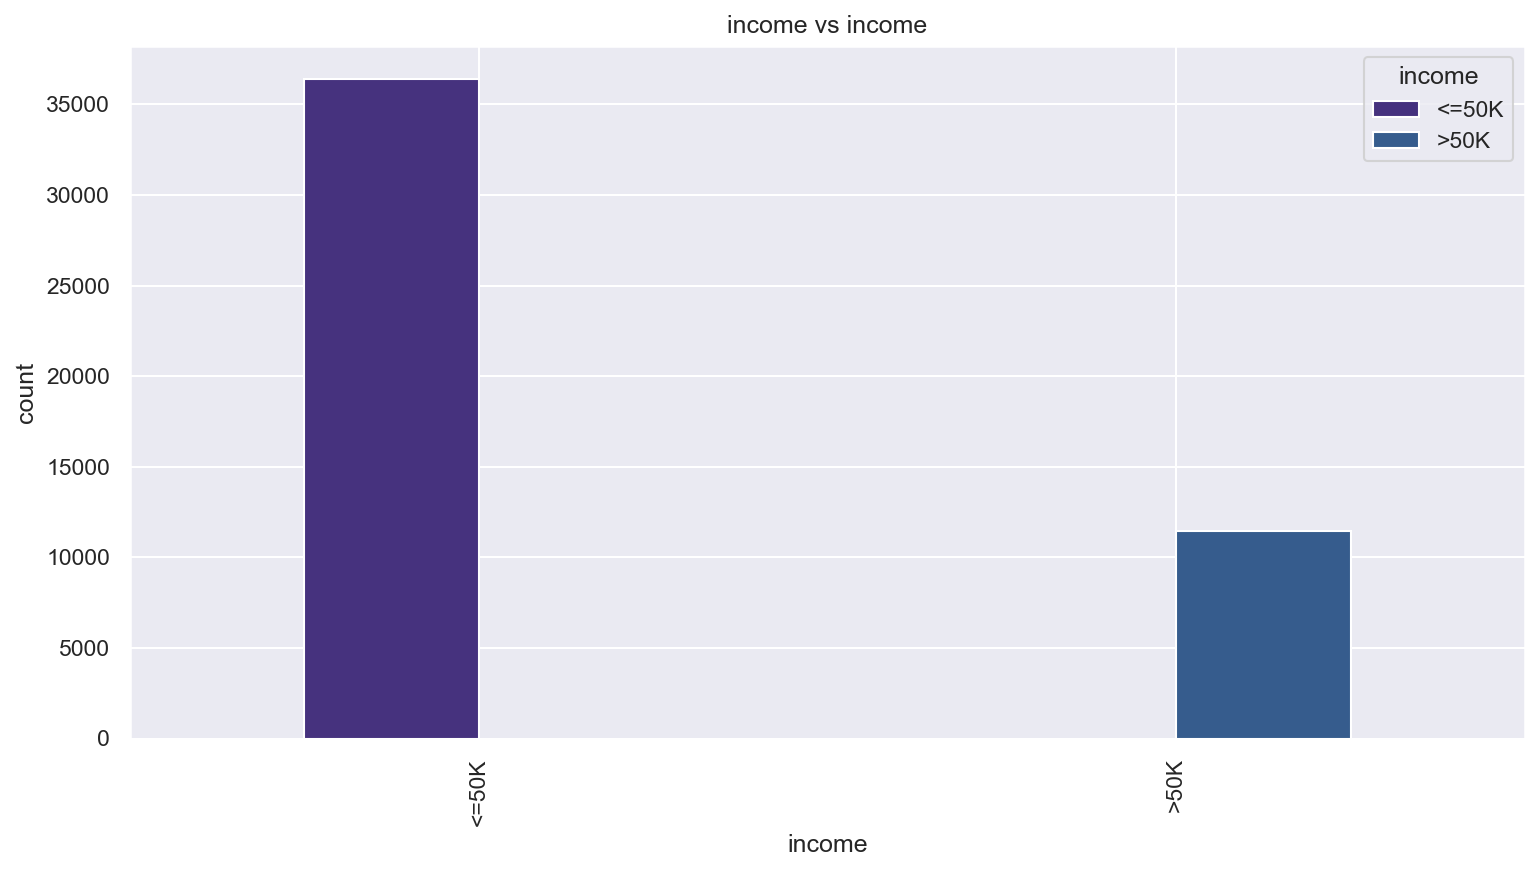

In [81]:
for i in txt_col:
    bar_by_income(i)

# Boxplot with numerical column

In [82]:
nums=df.select_dtypes([int,float]).columns
nums

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

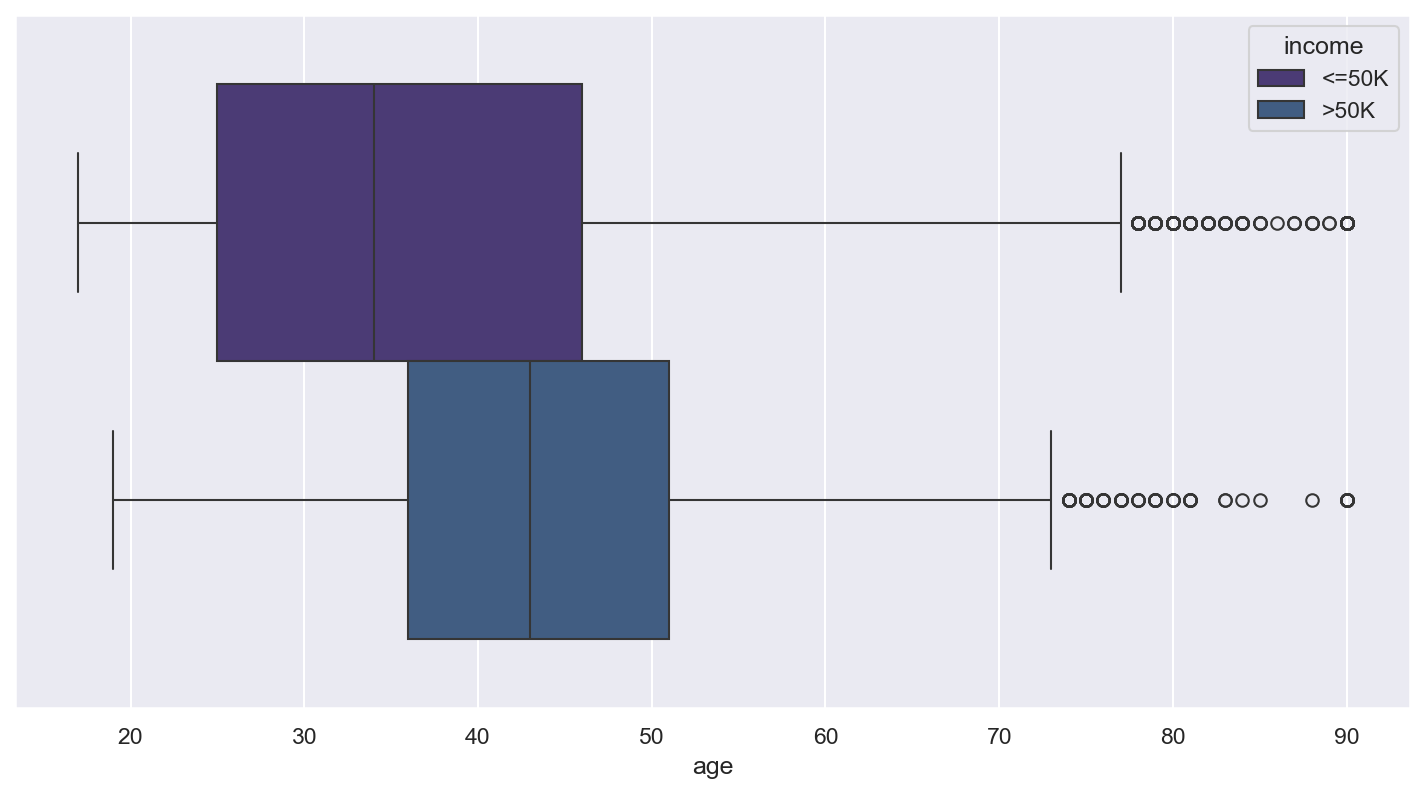

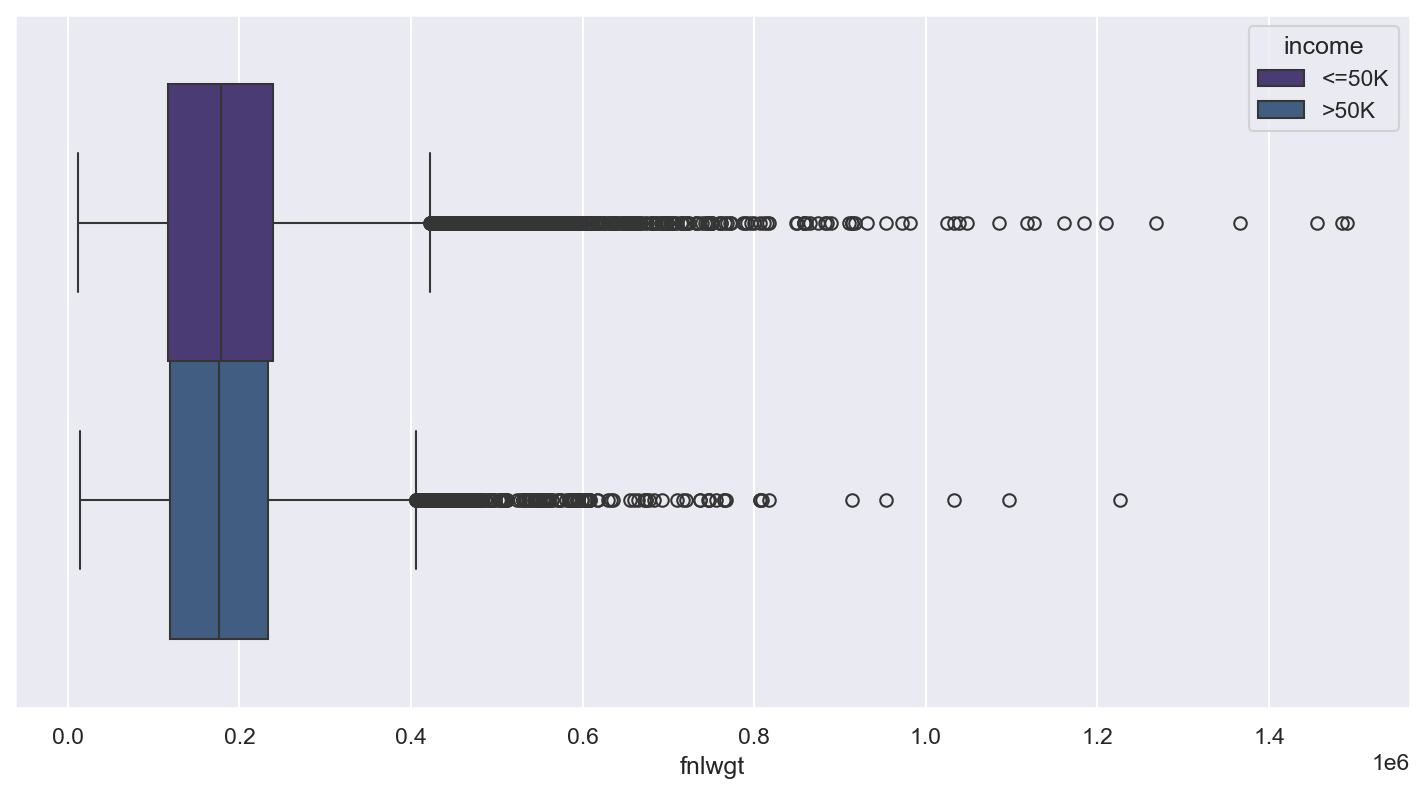

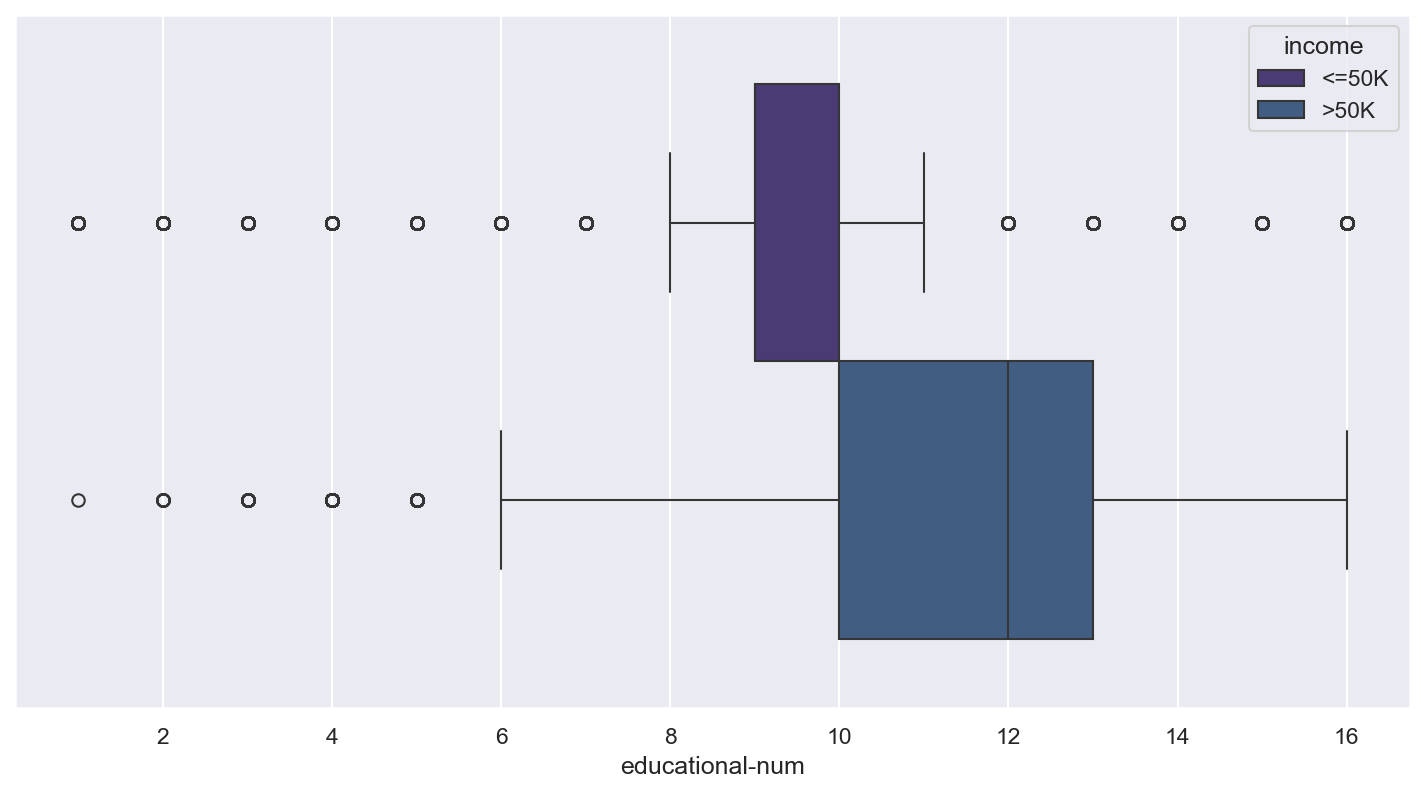

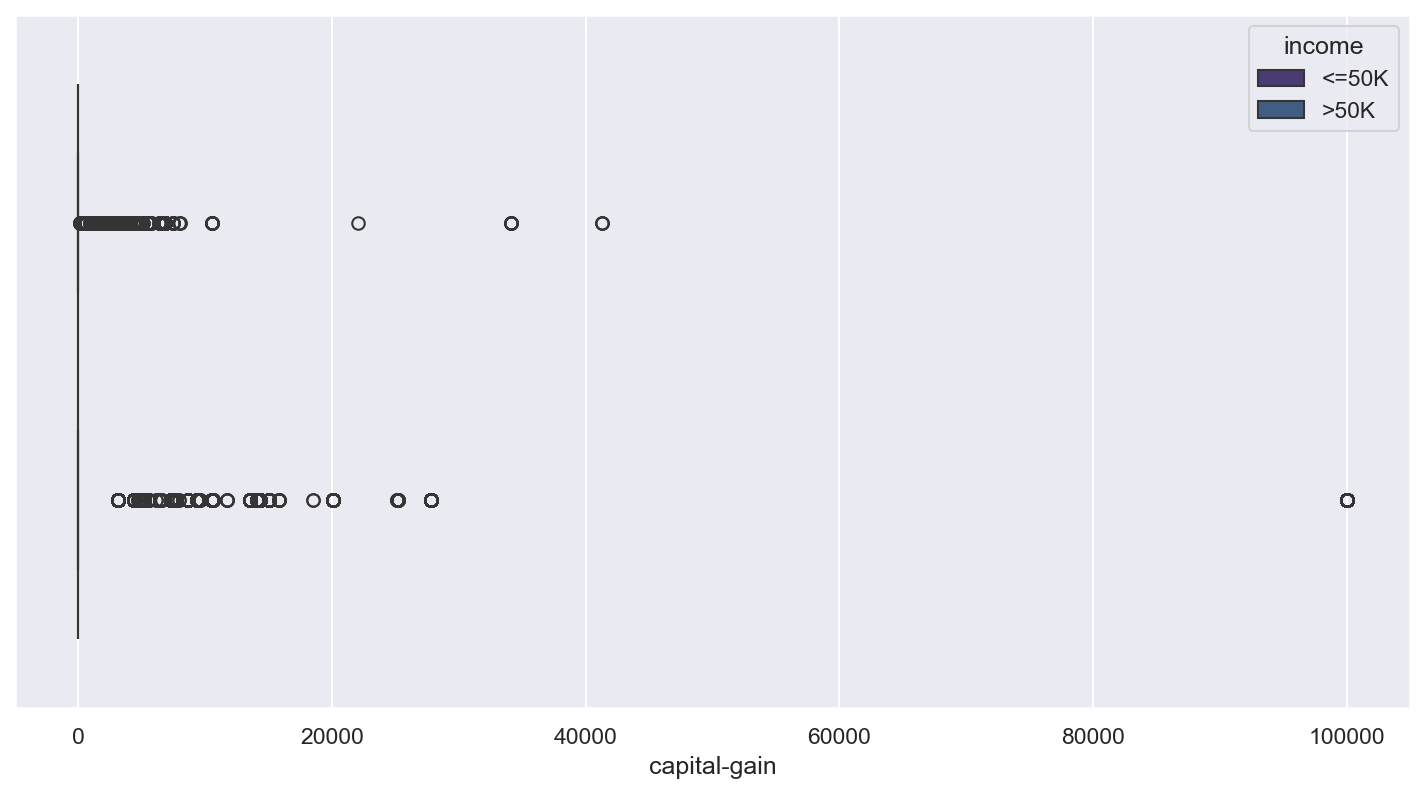

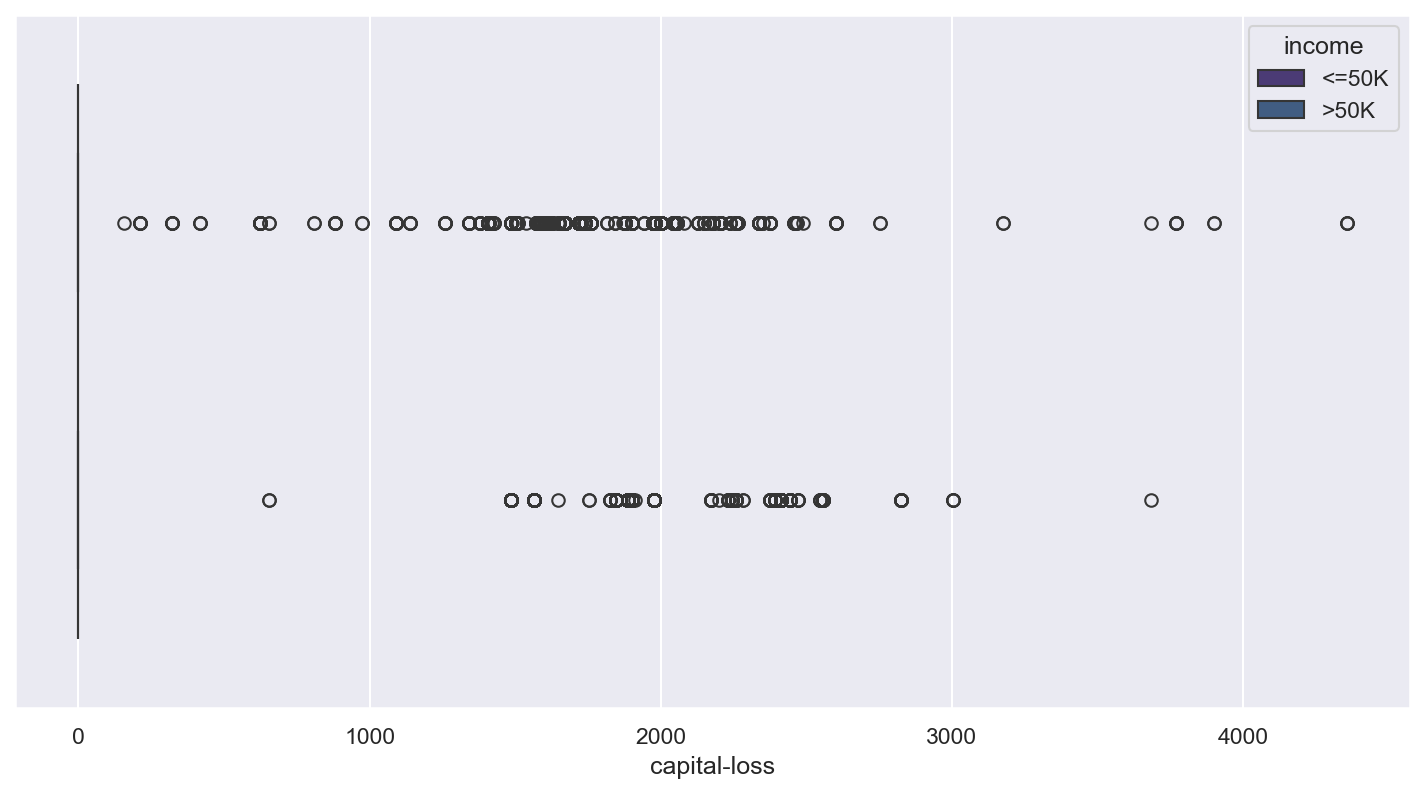

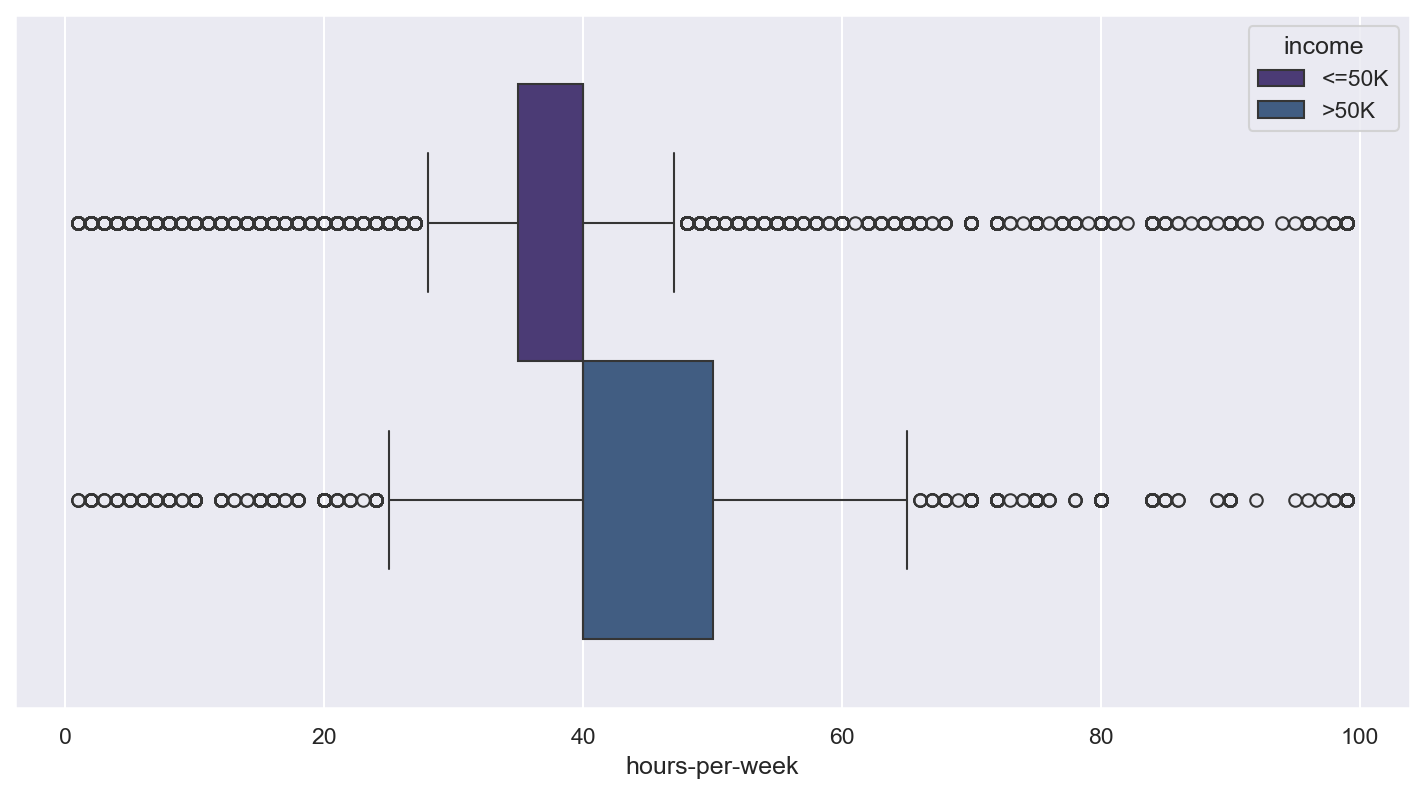

In [83]:
for i in nums:
    sns.boxplot(x=df[i],hue=df[target])
    plt.show()

In [84]:
df["age group"]=pd.cut(df["age"],bins=[0,25,35,50,65,90],labels=["Young","Early-carier","mid-carier","senior","old"])
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age group
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Young
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,mid-carier
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Early-carier
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,mid-carier
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K,Young


<Axes: xlabel='age group'>

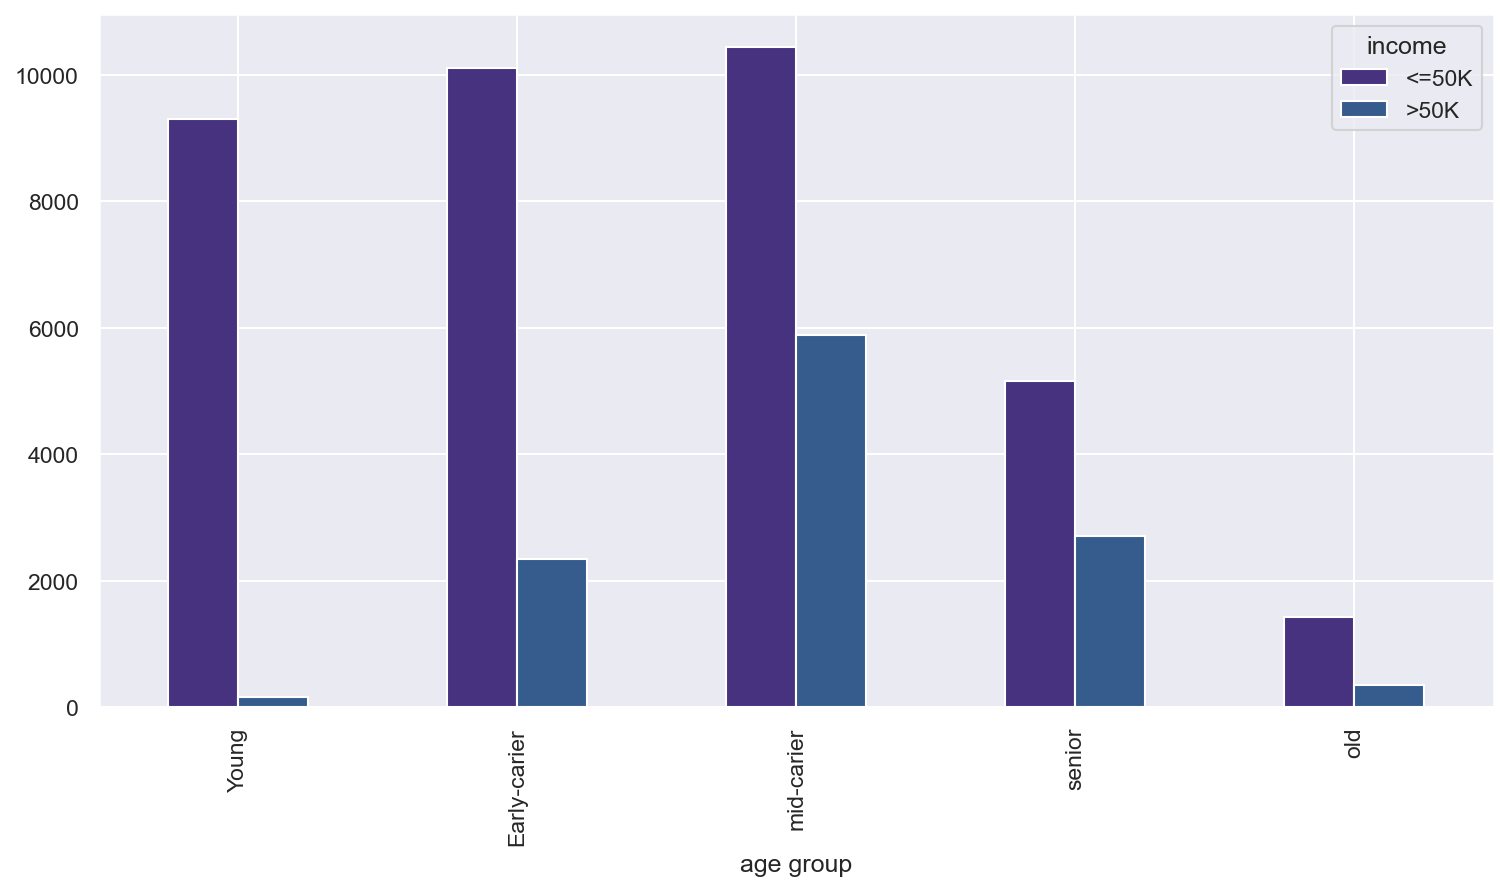

In [85]:
pd.crosstab(df["age group"],df["income"]).plot(kind="bar")

In [86]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,47874.000000,4.787400e+04,47874.000000,47874.000000,47874.000000,47874.000000
mean,38.652504,1.895868e+05,10.067887,1066.377073,87.426077,40.413836
std,13.730772,1.057877e+05,2.560012,7367.144472,402.834908,12.394358
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.173122e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.780700e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376708e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [87]:
df["per hour income"]=pd.cut(df["hours-per-week"],bins=[0,35,45,60,100],labels=["Part time","full time","over time","extream"])
df.head()


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age group,per hour income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Young,full time
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,mid-carier,over time
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Early-carier,full time
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,mid-carier,full time
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K,Young,Part time


<Axes: xlabel='per hour income'>

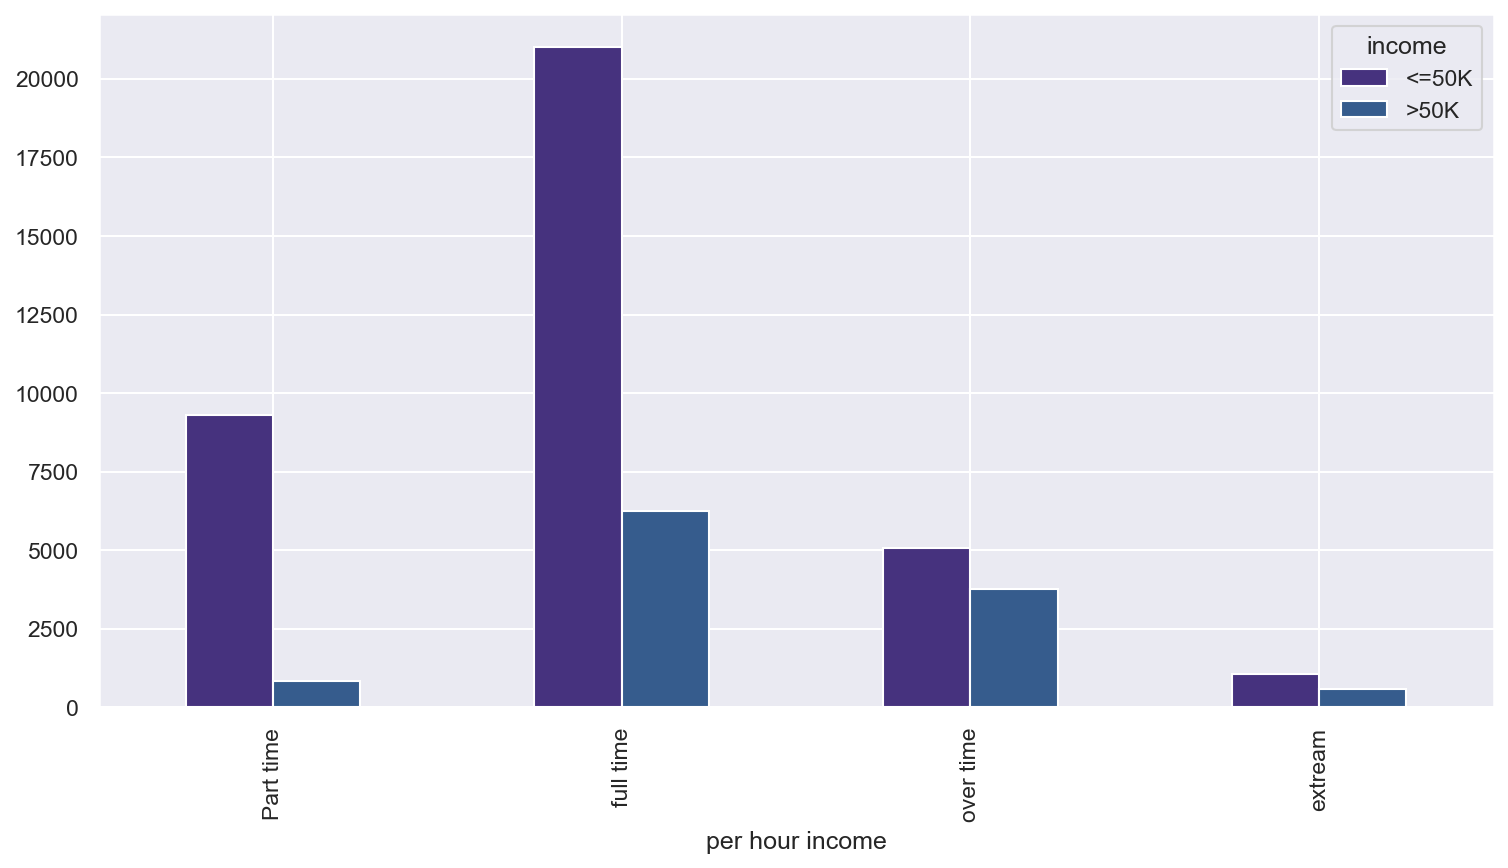

In [88]:
pd.crosstab(df["per hour income"],df["income"]).plot(kind="bar")

# 11.12.2025

In [89]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age group,per hour income
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Young,full time
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,mid-carier,over time
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Early-carier,full time
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,mid-carier,full time
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K,Young,Part time


In [90]:
df["capital-gain"].unique()

array([    0,  7688,  3103,  6418,  7298,  3908, 14084,  5178, 15024,
        2597,  2907,  4650,  6497,  1055,  5013, 27828,  4934,  4064,
        3674,  2174, 10605, 99999,  3418,   114,  2580,  3411,  4508,
        4386,  8614,  6849,  2463,  3137,  2885,  2964,  1471, 10566,
        2354,  1424,  1455,  3325,  4416, 25236,   594,  2105,  4787,
        2829,   401,  4865,  1264,  1506, 10520,  3464,  2653, 20051,
        4101,  1797,  2407,  3471, 13550,  1086,  1848, 14344,  1151,
        2993,  2290, 15020,  9386,  2202,  3818,  2176,  5455, 11678,
        7978,  7262,  6514, 41310,  3456,  7430,  2414,  2062, 34095,
        1831,  6723,  5060, 15831,  2977,  2346,  3273,  2329,  9562,
        2635,  4931,  1731,  6097,   914,  7896,  5556,  1409,  3781,
        3942,  2538,  3887, 25124,  7443,  5721,  1173,  4687,  6612,
        6767,   991,  2036,  2936,  2050,  1111,  2961,  2228, 22040,
        3432,  6360,  2009,  1639, 18481,  2387])

In [91]:
df["capital-gain"]>0

0        False
1        False
2        False
3         True
4        False
         ...  
48837    False
48838    False
48839    False
48840    False
48841     True
Name: capital-gain, Length: 47874, dtype: bool

# flagging called as converting data into binary formate

In [92]:
df["has-capital-gain"]=(df["capital-gain"]>0).astype(int)
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,age group,per hour income,has-capital-gain
0,25.0,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K,Young,full time,0
1,38.0,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K,mid-carier,over time,0
2,28.0,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K,Early-carier,full time,0
3,44.0,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K,mid-carier,full time,1
4,18.0,Private,103497,Some-college,10,Never-married,Craft-repair,Own-child,White,Female,0,0,30,United-States,<=50K,Young,Part time,0


<Axes: xlabel='has-capital-gain'>

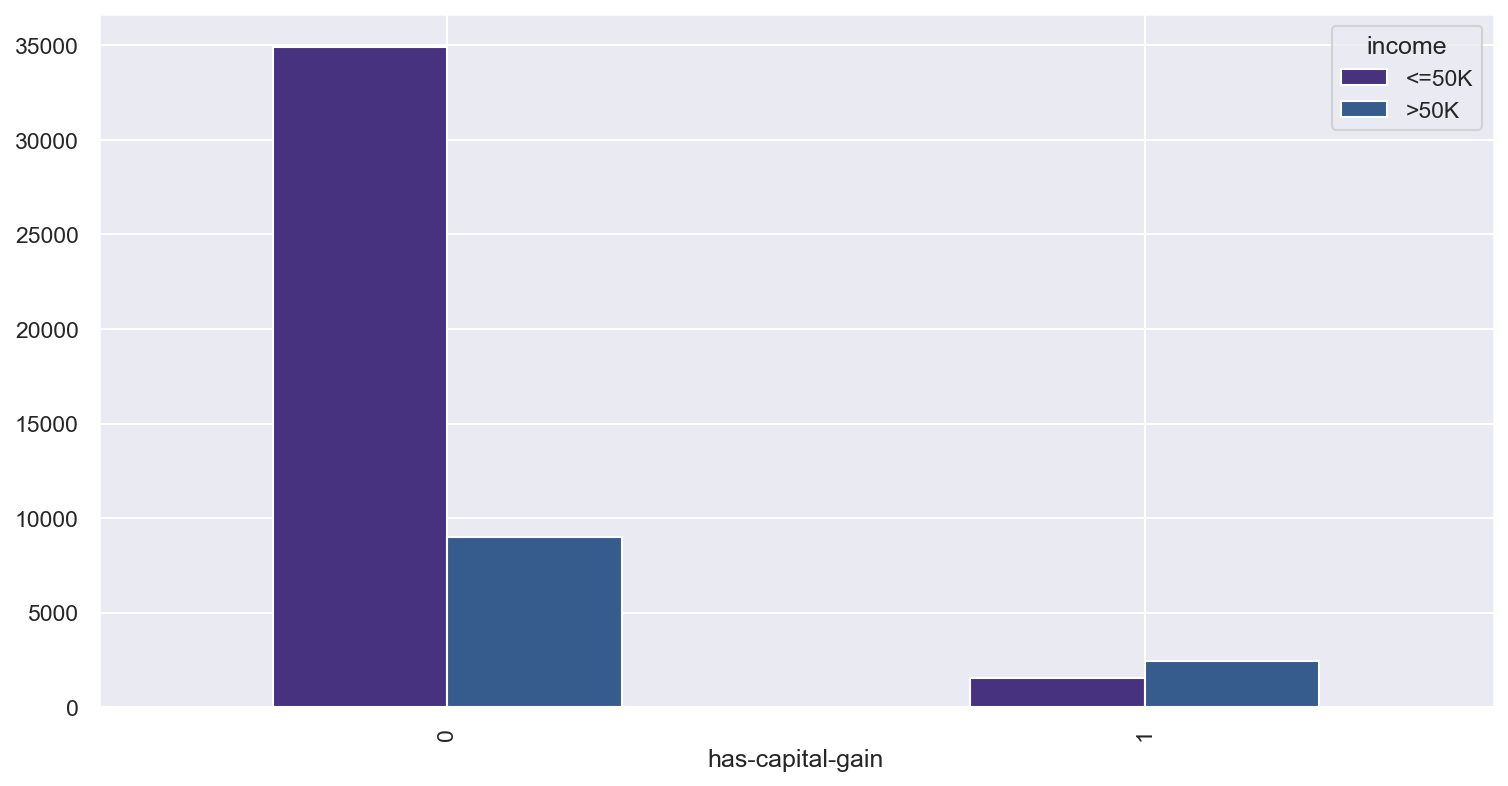

In [93]:
pd.crosstab(df["has-capital-gain"],df["income"]).plot(kind="bar")

In [94]:
df["marital-status"].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [95]:
df["marrid_flag"]=df["marital-status"].apply(lambda x:"married" if "Married" in x else "Unmarried")

In [96]:
df["marrid_flag"]

0        Unmarried
1          married
2          married
3          married
4        Unmarried
           ...    
48837      married
48838      married
48839    Unmarried
48840    Unmarried
48841      married
Name: marrid_flag, Length: 47874, dtype: object

# Check which occupation contributes more to the higher income (>50k)

<Axes: xlabel='occupation'>

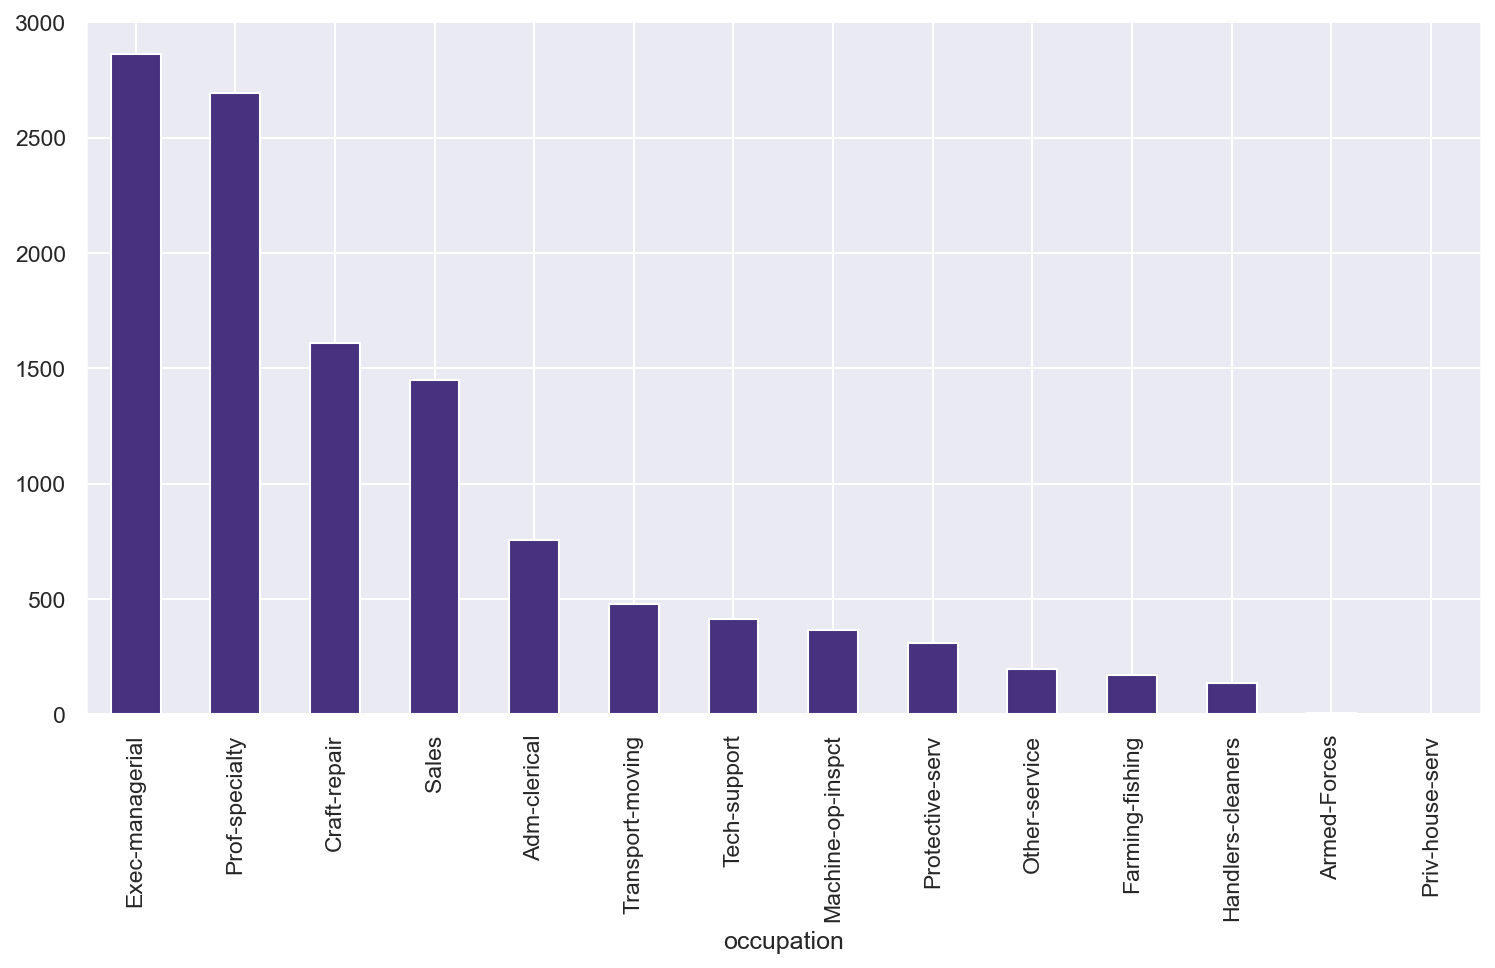

In [97]:
df[df["income"]==">50K"]["occupation"].value_counts().plot(kind="bar")  # can change["occupation"] column with another

# Corelation between numerical column 

In [98]:
df.corr(numeric_only=True)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,has-capital-gain
age,1.000000,-0.076524,0.030686,0.077112,0.056664,0.070382,0.119812
fnlwgt,-0.076524,1.000000,-0.040232,-0.003771,-0.004601,-0.013850,-0.007774
educational-num,0.030686,-0.040232,1.000000,0.125602,0.081603,0.144951,0.113873
capital-gain,0.077112,-0.003771,0.125602,1.000000,-0.031415,0.083020,0.482424
capital-loss,0.056664,-0.004601,0.081603,-0.031415,1.000000,0.053388,-0.065119
hours-per-week,0.070382,-0.013850,0.144951,0.083020,0.053388,1.000000,0.074993
has-capital-gain,0.119812,-0.007774,0.113873,0.482424,-0.065119,0.074993,1.000000


# Heatmap to find corelation

<Axes: >

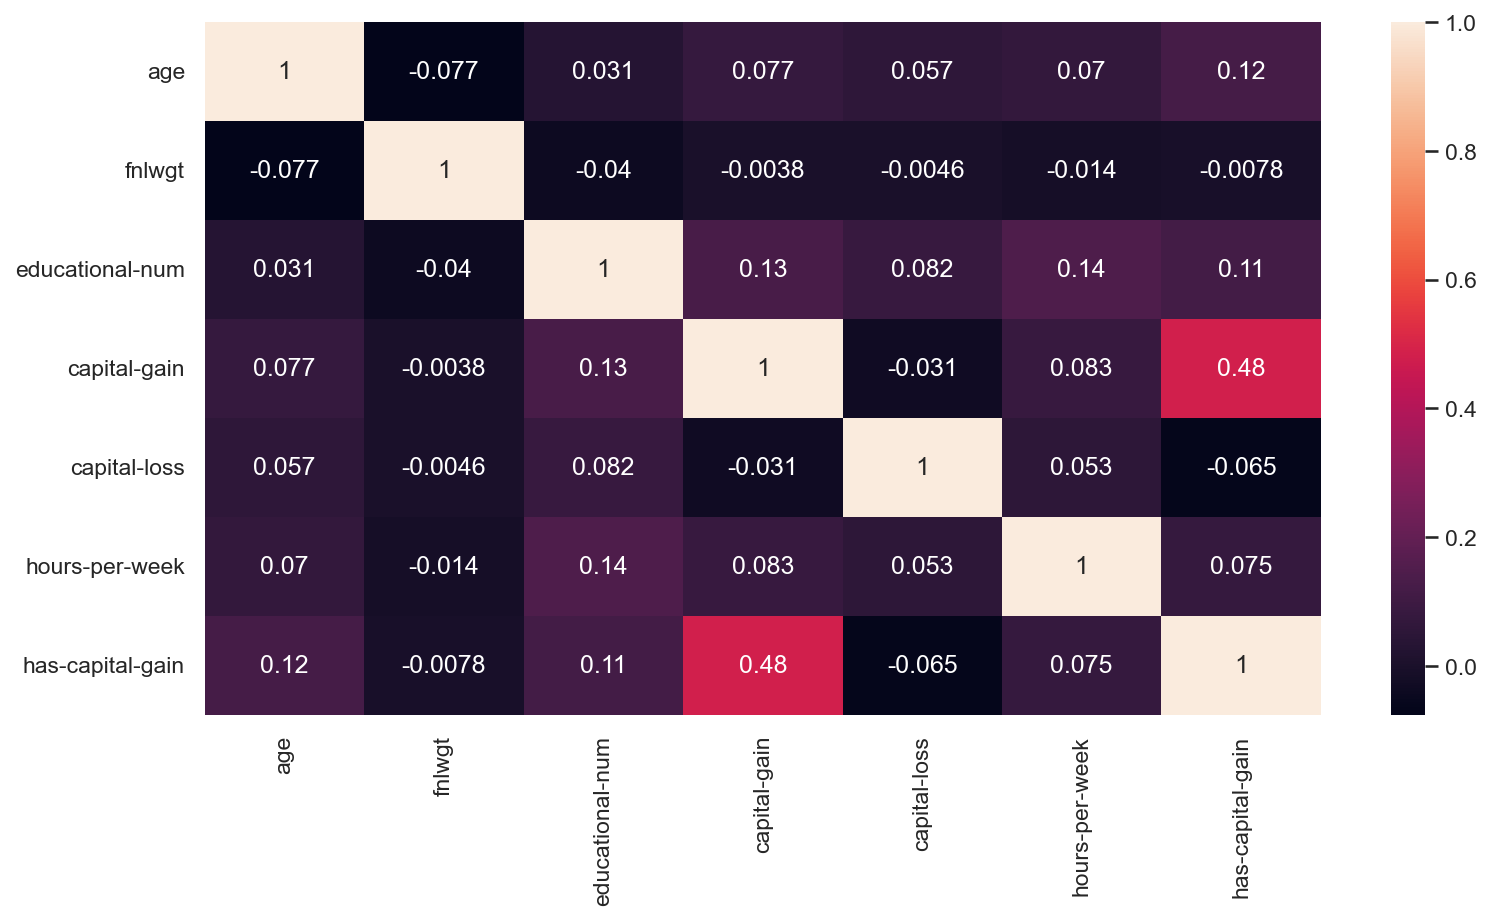

In [99]:
sns.heatmap(df.corr(numeric_only=True),annot=True) # annot is used to print the corelation value on top of the heat map

In [100]:
#  sns.heatmap(df.isna()) to check whether there are any null avlues are present 

In [101]:
grp=df.groupby(["workclass","income"]).size().unstack()

In [102]:
grp

income,<=50K,>50K
workclass,,
Federal-gov,856.0,549.0
Local-gov,2183.0,915.0
Never-worked,10.0,NaN
Private,28474.0,7489.0
Self-emp-inc,733.0,912.0
Self-emp-not-inc,2732.0,1056.0
State-gov,1424.0,520.0
Without-pay,19.0,2.0
